# 02 · Standard FunnyBird CBM: what happens when one part changes?

**Result in one sentence.** Controlled concept backwash exists in this
seed-1 Standard Koh Joint CBM, but it is graded rather than an all-parts-
behave-the-same effect: the inserted part moves the raw comparison
donorward, yet the old source remains higher in 50.2% of tail swaps,
20.0% of beak, 8.9% of eye, 3.2% of foot, and 1.9% of wing swaps.

**Required predicates and boundary.** The claim requires both
`response_delta>0` and final margin `m_cf<0` on the same validated
replacement. Visibility, label/mask conflict, and exact-value difficulty
align with the graded ordering and explain part of it. They do not make
the residual zero. Species information is abundant in raw concept scores,
but the current held-out categorical test gives source species no
generalizing explanatory credit. The report therefore concludes that
backwash exists, not that every cause is fully or causally identified.

**Starting question.** When one FunnyBird part is replaced while body,
pose, camera, and background stay fixed, what does the corresponding
concept output do? We do not label the result “backwash” unless the
predeclared response and final-margin conditions both hold.

**Population.** Standard non-RL CBM. This notebook contains no MCBM and no
visibility-aware relabelled model. Seed-level replication is shown where
accepted outputs exist; the fixed-render causal analysis begins with seed 1.
“Standard” here means training with the original concept labels. “Non-RL”
means those labels were not changed according to part visibility.

**What this design can establish.** FunnyBird's renderer permits a
controlled donor-part replacement. A validated positive donor response
plus a remaining source preference can establish the event. Visibility,
label conflict, exact value, support, and species are investigated only
after the event is measured; most remain proposed contributors unless
independently manipulated.


## The implemented standard CBM and the notation used below

This report uses the accepted **ResNet-50 Koh-architecture Joint CBM**, not the
CBM class from `minimal_cbm` and not an MCBM. For image `i`, the ResNet encoder
emits one raw logit for each of the 26 exact FunnyBird concepts. The single
linear species head reads those same 26 raw logits:

CBM means **concept bottleneck model**: instead of predicting species directly
from unspecified image features, it first produces named concept scores and
then predicts species from that bottleneck of scores. “Koh architecture” names
the published CBM design whose concept and class path is preserved here.

In ordinary language, ResNet-50 is the image-processing network. “Joint” means
the image-to-concept part and concept-to-species part are trained together
rather than in separate stages. A “linear species head” is one weighted sum per
species; it receives only the 26 concept scores, with no hidden nonlinear layer.

```text
image x_i
   |
   v
ResNet-50 image encoder
   |
   v
26 raw concept logits z_i = (z_i1, ..., z_i26)
   |                         |
   |                         +--> sigmoid only for thresholded concept metrics
   |
   +--> one linear 26-to-50 species head --> species logits
```

Training minimizes Koh Joint's normalized task-plus-concept loss:

`L = L_task + 0.01 * L_concept`.

`L_task` penalizes wrong species answers. `L_concept` penalizes disagreement
with the 26 supplied concept labels. The factor 0.01 controls their numerical
weight during training; it is not a statement that concepts matter only 1% to
the final prediction.

The class head receives raw `z`; it does not receive probabilities or hard 0/1
concept decisions. There is no learned `1 -> 3 -> 1` concept decoder in this
model. The image encoder is the professor-approved ResNet-50 substitution for
Koh's Inception-v3 encoder. The accepted training description is
`ResNet-50 Koh-architecture Joint CBM, accelerated_v1`, followed by the matched
low-learning-rate convergence continuation recorded in the manifest.
`accelerated_v1` names the declared optimizer, batch, precision, and
learning-rate schedule used to finish training more quickly. It does not replace
the Koh Joint concept bottleneck with an MCBM.

| Symbol | Plain meaning | Use below |
|---|---|---|
| `x_i` | image `i` | model input |
| `y_i` | species label | species-task health |
| `c_ij` | processed 0/1 label for exact concept `j` | concept supervision and health |
| `z_ij` | raw logit emitted for concept `j` | primary grounding quantity |
| `p_ij = sigmoid(z_ij)` | bounded probability | thresholded performance only |
| `c_hat_ij = 1[z_ij>0]` | predicted present/absent concept | recall and balanced accuracy |
| `v_ig` | whether renderer mask `g` is visible | visibility analysis |
| `a_ig` | visible mask area | visibility-strength analysis |

Example: `z_blue_tail=+4` means the model favors “blue tail”; `z_blue_tail=-4`
means it disfavors it. The size of a raw-logit difference is measured in logit
units and is not a probability-point difference.

Ordinary accuracy and recall answer whether the model agrees with labels on
ordinary images. They do **not** establish which pixels produced `z`.


## A new reader's guide: one complete replacement in ordinary language

Suppose the original bird has a **red tail** and we replace only that tail with
a **blue tail** taken from another species.

- The bird receiving the replacement is the **source** bird.
- The species that supplied the blue tail is the **donor**.
- “Red tail” and “blue tail” are two **exact concepts**: specific possible
  values of the broader part “tail.”
- The unchanged picture is the **original**. The otherwise identical picture
  containing the blue tail is the **replacement** or **counterfactual**.
- A **mask** is an image marking which pixels belong to one part. If the blue
  tail mask contains 150 pixels, its visible size is 150 pixels.

The model gives every exact concept an unbounded numerical score called a
**raw logit**, written `z`. Larger means “the model favors this answer more”;
smaller means “it favors it less.” A raw logit is not a percentage. For example,
`z_blue=+4` and `z_red=+1` means blue is favored over red by three logit
units. Applying `sigmoid(z)` produces a probability-like number only when a
thresholded yes/no performance question requires it.

The **margin** compares the two relevant answers:

`margin = blue-tail score - red-tail score`.

- margin `+3`: blue finishes three units above red, so the inserted answer wins;
- margin `-3`: red remains three units above blue, so the old answer wins.

The **response change** (`response_delta`) asks how much that margin moved
toward blue after the pixels changed. Worked example:

1. Before replacement, blue scores `-7` and red scores `+3`, so the starting
   margin is `-7 - 3 = -10`.
2. After replacement, blue scores `+1` and red scores `+2`, so the final
   margin is `+1 - 2 = -1`.
3. The margin moved from `-10` to `-1`, so
   `response_delta = -1 - (-10) = +9`.

The model plainly reacted to the blue pixels because the comparison moved nine
units toward blue, but it still answered red more strongly because the final
margin is negative. That combination—positive response change and negative
final margin—is the report's controlled **backwash event**.

### Other terms used later

| Term | Ordinary meaning | Small example |
|---|---|---|
| rate or fraction | count satisfying a rule divided by all eligible rows | 20 events among 100 swaps gives 0.20 or 20% |
| median | middle value after sorting | the median of 1, 3, 9 is 3 |
| percentile | a location in a sorted distribution | Q95 is greater than or equal to 95% of observed values |
| balanced accuracy | average of success on positive and negative labels | 90% positive recall and 70% negative recall gives 80% |
| visibility bin | replacements grouped by target-part pixel count | 100–199 means the inserted part contains from 100 through 199 pixels |
| label/mask conflict | label says the concept is present while its renderer mask says its pixels are not visible | “red tail=1” but zero red-tail-region pixels |
| exact-value recognition | whether the inserted value receives the largest score among alternatives for that part | blue is highest among nine tail values |
| species support | how many of the 50 species naturally carry an exact value in an unmodified bird; it is not the number of images or swaps | support 4 for blue tail means four species normally have blue tails, even if the experiment renders many blue-tail swaps |
| species decoder | a separate diagnostic classifier trained after the CBM; it asks whether species can be guessed from concept numbers | 70% means 70 of 100 held-out species labels are guessed correctly |
| held-out | rows not used to fit the diagnostic rule being evaluated | fit on four folds and score on the fifth |
| fold | one non-overlapping held-out subset | five-fold testing uses each of five subsets once as the test set |
| RMSE | typical prediction error, with large mistakes penalized more | lower RMSE is better; 3.1 is better than 3.8 |
| residual | what remains after subtracting the comparison group's expected value | observed margin 5 minus expected margin 3 leaves residual +2 |
| association | two measurements vary together; the cause is not isolated | larger visible tails tend to have better margins |
| causal evidence | changing one thing while holding the relevant alternatives fixed changes the outcome | the renderer replaces one part in the same scene |
| grounding | the named concept score actually follows the pixels of that named part | blue-tail score follows replacement blue-tail pixels |
| model health | basic check that an output changes and agrees with ordinary labels | a constant score is unhealthy even if one class is common |
| collapsed output | a score that is effectively identical for every image | always returning `z=2` cannot distinguish presence from absence |
| seed 1 | one fixed random initialization/run identifier | other seeds are independent replications, not extra images in an error bar |
| RLv2 | the later matched model trained after changing positive labels to zero when their part is invisible | used for the causal label test in notebook 02rl, not for the discovery result here |

Figures 3–4 provide causal evidence about the inserted pixels because the
renderer holds the rest of the scene fixed. Later comparisons of visibility,
value frequency, or species are mostly associations: they can identify a
plausible contributor without proving that contributor alone caused the event.


## Investigation map: what would count as backwash?

We begin without assuming that backwash exists. A FunnyBird replacement will
count as a **backwash event** only if both of the following occur on the *same
controlled replacement*:

1. the donor part moves the raw concept comparison toward the donor
   (`response_delta > 0`); and
2. after that movement, the old source concept is still higher
   (`m_cf < 0`).

Numerical example—not a reported result: replacing a red tail with a blue tail
raises the blue-tail score relative to red by 24 units, but red still finishes
6 units above blue. The model reacted to the new tail pixels, yet its final
concept answer remained attached to the old bird. Figure 4 asks whether this
pattern actually appears in the accepted data.

**Part names are outcomes, not mechanisms.** The proposed general mechanism is
competition between the original context-driven source preference and the
response caused by the inserted part pixels. Visibility/label conflict,
exact-value difficulty, alternative frequency, and source-species organization
may change that balance for any part. FunnyBird tail is the most severe observed
example, but all five parts are measured and CUB must establish its own ordering.

The investigation stops or changes direction if an earlier gate fails. It asks:

| Step | Needed fact | Figure(s) | Why it is needed |
|---|---|---|---|
| 1 | the trained concept outputs are usable | 1 | a constant or broken output cannot support grounding analysis |
| 2 | the renderer really changed only the named part | 2 | otherwise a score change cannot be assigned to that part |
| 3 | the inserted pixels cause donorward movement | 3 | proves the model saw some evidence in the new part |
| 4 | starting preference, donor rise, and old-source decrease are separated | 3b | distinguishes starting context from response magnitude |
| 5 | the old source can still win after that movement | 4, 4b | this is the controlled backwash predicate and its complementary outcomes |
| 6 | the event is not a direction-averaging artifact | 5 | checks forward and reverse replacements separately |
| 7 | test proposed contributors | 6–8 | visibility/occlusion, conflicting labels, exact-value difficulty, support/alternatives, and source species |
| 8 | separate species-information availability, saved-head use, and controlled-outcome linkage | 8b–8d | prevents calling decodable leakage a causal mechanism |
| 9 | measure what those contributors predict and what remains | 9 | prevents claiming that a plausible story explains all rows |
| 10 | measure downstream class impact | 10 | separates explanation failure from species-classification harm |

### The three contributor hypotheses carried into both reports

The linked comparison tests the same three proposed reasons in the same order:

1. **visibility/occlusion:** the named pixels may be absent or too small;
2. **label–visibility conflict:** training may call a concept positive when its
   mapped region is not visible; and
3. **exact-value difficulty:** some variants may be intrinsically harder, rarer,
   or drawn from a larger alternative set.

Only after those are measured do we ask whether unchanged source species/body
context organizes the remaining raw-score error.  That fourth term is a
residual association, not a promise that the three measured reasons sum to the
whole phenomenon.

The final mechanistic follow-up distinguishes three different statements that
must not be collapsed into one:

1. species can be decoded from the raw concept scores (**information is
   available**);
2. the saved linear species head changes its own decision when within-label
   score magnitudes are removed (**the existing CBM uses that information**);
3. retained source-species evidence on controlled replacements predicts a more
   source-negative final concept margin (**the information is linked to the
   backwash outcome**).

Only the third statement can promote distributed species information from a
leakage diagnostic to a candidate mechanism. Even then, species is bundled with
body shape and pose, so it remains a mechanistic association rather than an
independent species intervention.

The implementation retains the complete renderer audit, all exact values,
species residuals, recall/model-health controls, and provenance inherited from
the earlier curated report and the original renderer-swap and recall notebooks.

### Capabilities and limits that determine this design

FunnyBird supplies an exact renderer mask and a clean donor-part replacement:
body, pose, camera, and background can remain unchanged while one part changes.
That makes Figures 3–4 causal tests of the changed part pixels. Visibility,
training-label conflict, exact value, support, and species are then investigated
as possible contributors. Except for the later matched RLv2 retraining, those
contributor analyses are observational and are not allowed to erase the
controlled event or claim that every cause has been found.

### Predictions stated before the results

- If the concept is locally grounded, replacement should produce
  `response_delta > 0` and usually `m_cf > 0`.
- If backwash occurs, a nontrivial set should have `response_delta > 0` but
  `m_cf < 0`.
- If visibility/occlusion is sufficient, the event should disappear for large,
  clearly visible inserted parts.
- If label–visibility conflict contributes, parts with more positive labels on
  invisible parts should later improve most under matched RLv2 training.
- If exact-value difficulty or species context contributes, matched rows should
  retain systematic value- or species-linked differences.
- None of these predictions requires the measured contributors to reduce the
  remaining error to zero.

### Relation to existing CBM intervention and leakage work

The original [Concept Bottleneck Models paper](https://proceedings.mlr.press/v119/koh20a.html)
intervenes by editing a predicted concept value before the task head. That tests
whether changing the bottleneck changes the final task output; it does not test
whether image-to-concept prediction used the named pixels. Work on
[information leakage in soft CBMs](https://arxiv.org/abs/2211.03656) motivates
the label-versus-raw-score control because soft scores can contain information
beyond their nominal concepts. Spatially aware CBMs explicitly introduce local
concept maps and region editing, illustrating why a spatial constraint is a
different method from merely compressing a scalar bottleneck
([Benou et al., 2025](https://openaccess.thecvf.com/content/CVPR2025/html/Benou_Show_and_Tell_Visually_Explainable_Deep_Neural_Nets_via_Spatially-Aware_CVPR_2025_paper.html)).

Our renderer swap therefore supplies a distinct base-case intervention: it
changes the named pixels first and observes the concept score afterward. The
leakage tests are supporting mechanism diagnostics and cannot replace that
controlled grounding test.


## Dataset design and report population

FunnyBird is synthetic, so the relevant objects are known exactly rather than
estimated from photographs.

| Item | Value used here | Why it matters |
|---|---:|---|
| species | 50 | unchanged species/body appearance is the possible contextual signal |
| named parts | `tail`, `wing`, `beak`, `foot`, `eye` | these are the only five FunnyBird part names used below |
| exact concepts | 26 part values across the five parts | for example, `tail::blue`; a part and its exact value are not interchangeable |
| held-out model-health population | 500 test images | used for Figure 1 and the species decoder |
| controlled swap population | accepted fixed-render seed-1 CSV | the same validated rendered images are reused across model comparisons |

Species determine part values in FunnyBird, so species context can predict a
concept label even when the named part is hard to see. That makes contextual
prediction possible, but it does not prove the trained CBM used context. The
controlled replacement in Figures 2–4 supplies that stronger test.


In [1]:
import os, json, re, glob, sys, hashlib, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image as DisplayImage

CURATED = Path(os.environ["CURATED_DATA"])
CWD = Path.cwd()
REPO = CWD if (CWD/"analysis").is_dir() else CWD.parent
sys.path.insert(0, str(REPO/"data"/"funnybirds"))
plt.rcParams.update({"figure.dpi": 120, "axes.grid": False})
pd.set_option("display.max_rows", 250)
pd.set_option("display.max_columns", 40)
ORDER = ["tail", "wing", "beak", "foot", "eye"]
COLORS = {"tail":"#6A0DAD", "wing":"#0072B2", "beak":"#E69F00",
          "foot":"#009E73", "eye":"#CC79A7"}

def require(path, command):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}\nProduce it with: {command}")
    return path

MODEL_ROOT = CURATED/"koh_joint_resnet_accelerated_converged_v1"/"funnybirds"/"standard"/"seed1"
SWAP_ROOT = CURATED/"swap_koh_joint_resnet_accelerated_converged_v1_seed1"
MODEL_MANIFEST = require(MODEL_ROOT/"SUCCESS.json", "complete accepted FunnyBird Standard convergence")
SWAP_MANIFEST = require(SWAP_ROOT/"SUCCESS.json", "complete accepted converged FunnyBird fixed swaps")
for manifest_path in [MODEL_MANIFEST, SWAP_MANIFEST]:
    subprocess.run([sys.executable, str(REPO/"analysis"/"canonical_manifest.py"),
                    "verify", "--manifest", str(manifest_path)], check=True)
subprocess.run([sys.executable, str(REPO/"analysis"/"validate_fixed_swaps.py"),
                "--out", str(SWAP_ROOT)], check=True)
model_manifest = json.loads(MODEL_MANIFEST.read_text())
swap_manifest = json.loads(SWAP_MANIFEST.read_text())
expected_model_meta = {"framework":"koh_joint", "backbone":"resnet50",
                       "dataset":"funnybirds", "labels":"standard", "seed":"1"}
for key,value in expected_model_meta.items():
    if model_manifest.get("metadata",{}).get(key) != value:
        raise RuntimeError(f"model manifest {key} is not {value!r}")
if swap_manifest.get("metadata",{}).get("framework") != "koh_joint":
    raise RuntimeError("swap manifest is not Koh Joint")
SWAP = require(SWAP_ROOT/"funnybirds-cbm-s1.csv", "run accepted converged swaps")
S = pd.read_csv(SWAP)
# The Koh Joint model emits these raw concept logits directly. Legacy
# CSV column names are retained only as a file-schema compatibility layer.
if "response_delta" not in S:
    S["response_delta"] = S.margin - (S.z_new_orig - S.z_old_orig)
required_swap_columns={"z_new","z_old","z_new_orig","z_old_orig","margin","response_delta"}
missing_swap_columns=required_swap_columns-set(S.columns)
if missing_swap_columns:
    raise RuntimeError(f"accepted swap CSV is missing {sorted(missing_swap_columns)}")
S["m_orig"] = S.z_new_orig - S.z_old_orig
S["m_cf"] = S.z_new - S.z_old
S["donor_gain"] = S.z_new - S.z_new_orig
S["source_decrease"] = S.z_old_orig - S.z_old
if not np.allclose(S.m_cf,S.margin):
    raise RuntimeError("stored final margin disagrees with z_new-z_old")
if not np.allclose(S.m_cf,S.m_orig+S.donor_gain+S.source_decrease):
    raise RuntimeError("starting-margin/response decomposition does not close")
S["responded_but_source_wins"] = (S.response_delta > 0) & (S.margin < 0)
print("fixed-render input:", SWAP)
print("rows:", len(S), "parts:", sorted(S.part.unique()))

PRED = require(MODEL_ROOT/"final_test.parquet", "complete accepted FunnyBird Standard evaluation")
MODEL = require(MODEL_ROOT/"final_model_1.pth", "complete accepted FunnyBird Standard convergence")
EVAL = pd.read_parquet(PRED)
required_eval_columns={"image","y_true","y_pred","concept_index","concept_name","z","prob","gt_label"}
missing_eval_columns=required_eval_columns-set(EVAL.columns)
if missing_eval_columns:
    raise RuntimeError(f"Koh evaluation is missing {sorted(missing_eval_columns)}")
if len(EVAL) != EVAL.image.nunique()*26:
    raise RuntimeError("Koh evaluation is not one row per image and exact concept")
concept_order=(EVAL[["concept_index","concept_name"]].drop_duplicates()
               .sort_values("concept_index"))
if concept_order.concept_index.tolist() != list(range(26)):
    raise RuntimeError("Koh evaluation concept indices are not exactly 0..25")
image_order=EVAL.image.drop_duplicates().tolist()
z_saved=(EVAL.pivot(index="image",columns="concept_index",values="z")
         .reindex(image_order).to_numpy())
p_saved=(EVAL.pivot(index="image",columns="concept_index",values="prob")
         .reindex(image_order).to_numpy())
c_saved=(EVAL.pivot(index="image",columns="concept_index",values="gt_label")
         .reindex(image_order).to_numpy())
image_labels=(EVAL[["image","y_true","y_pred"]].drop_duplicates("image")
              .set_index("image").reindex(image_order))
y_saved=image_labels.y_true.to_numpy(dtype=int)
y_pred_saved=image_labels.y_pred.to_numpy(dtype=int)
if not np.allclose(1/(1+np.exp(-z_saved)),p_saved,rtol=1e-5,atol=1e-6):
    raise RuntimeError("Koh evaluation probability does not equal sigmoid(raw z)")

FB_ROOT = Path(os.environ.get("FUNNYBIRDS_ROOT", CURATED/"FunnyBirds"))
import funnybirds_concepts as fbc
parts = fbc.load_parts(FB_ROOT)
CONCEPT_NAMES = fbc.concept_names(parts)
SPANS = fbc.group_slices(parts)
if concept_order.concept_name.tolist() != CONCEPT_NAMES:
    raise RuntimeError("FunnyBird concept names/order disagree with the Koh evaluation")
if len(CONCEPT_NAMES) != z_saved.shape[1]:
    raise RuntimeError("parts.json concept width does not match saved predictions")
CONCEPT_PART = {name: part for part,(a,b) in SPANS.items() for name in CONCEPT_NAMES[a:b]}
print("framework: Koh Joint; backbone: ResNet-50; minimal_cbm: rejected")
print("checkpoint:", MODEL)
print("evaluation:", PRED, "images:", len(y_saved), "concepts:", len(CONCEPT_NAMES),
      "species:", len(np.unique(y_saved)))


[MANIFEST VERIFIED] /scratch/network/cr7998/cv_emergence_project/curated_data/koh_joint_resnet_accelerated_converged_v1/funnybirds/standard/seed1/SUCCESS.json
[MANIFEST VERIFIED] /scratch/network/cr7998/cv_emergence_project/curated_data/swap_koh_joint_resnet_accelerated_converged_v1_seed1/SUCCESS.json


[checked] funnybirds-cbm-rlv2matched-s1.csv: 5000 fixed renders; unique_cf_hashes=3040; unique_orig_hashes=250; changed_from_orig=0.983
[checked] funnybirds-cbm-s1.csv: 5000 fixed renders; unique_cf_hashes=3040; unique_orig_hashes=250; changed_from_orig=0.983
FIXED SWAP VALIDATION PASSED: 2 model CSVs, 5000 counterfactual RGB IDs, 250 original RGB IDs; hashes agree across models and each CSV passed diversity/intervention checks.
fixed-render input: /scratch/network/cr7998/cv_emergence_project/curated_data/swap_koh_joint_resnet_accelerated_converged_v1_seed1/funnybirds-cbm-s1.csv
rows: 5000 parts: ['beak', 'eye', 'foot', 'tail', 'wing']
framework: Koh Joint; backbone: ResNet-50; minimal_cbm: rejected
checkpoint: /scratch/network/cr7998/cv_emergence_project/curated_data/koh_joint_resnet_accelerated_converged_v1/funnybirds/standard/seed1/final_model_1.pth
evaluation: /scratch/network/cr7998/cv_emergence_project/curated_data/koh_joint_resnet_accelerated_converged_v1/funnybirds/standard/see

## 1 · Did training produce a usable, non-collapsed CBM?

**Question.** Did training produce a usable, non-collapsed CBM?

**Variables and prediction.** For every exact concept `j`, measure raw-score spread, positive-versus-negative label separation, balanced accuracy, and positive recall. A usable slot has nonzero spread, positive label separation, and above-chance thresholded performance.

**Method.** Compute all quantities from the epoch-100 held-out predictions. Recall is a health statistic, not grounding evidence.

### Figure 1 · Did training produce a usable, non-collapsed CBM?

**How to read the figure.** Each row is one exact concept, such as `yellow tail`. The four panels use the
same rows. `spread = Q95(z)-Q05(z)` asks whether the output changes across
test images; exactly zero means a constant output. `label separation =
median(z|c=1)-median(z|c=0)` asks how far positive-labelled images sit above
negative-labelled images; positive is the expected direction. `balanced
accuracy = (positive recall + negative recall)/2` gives positive and negative
labels equal weight; 0.5 is chance for a binary concept. `positive recall =
P(z>0|c=1)` is the fraction of labelled-positive images called positive.
Example: positive recall 0.90 means 90 of 100 positive-labelled images have
`z>0`. Dot color identifies the FunnyBird part: purple tail, blue wing,
orange beak, green foot, and pink eye. The solid zero line marks no label
separation; the dashed 0.5 lines mark chance balanced accuracy and 50%
positive recall. These are health checks, not evidence about which pixels
produced `z`.


,images,species,task_accuracy,concept_accuracy
0,500,50,0.992,0.9968


,concept,part,spread,label_separation,balanced_accuracy,positive_recall,n_positive,n_negative
0,beak_0,beak,10.054,8.069,0.994,0.990,210,290
1,beak_1,beak,12.014,10.326,0.994,0.990,100,400
2,beak_2,beak,13.487,11.214,0.999,1.000,60,440
3,beak_3,beak,11.431,8.898,0.996,0.992,130,370
4,eye_0,eye,11.156,9.241,0.989,0.987,150,350
5,eye_1,eye,10.891,8.934,0.988,0.975,160,340
6,eye_2,eye,10.699,8.428,0.985,0.979,190,310
7,foot_0,foot,11.098,8.940,0.999,1.000,130,370
8,foot_1,foot,11.551,9.560,0.995,0.990,100,400
9,foot_2,foot,11.267,8.639,0.993,0.986,140,360


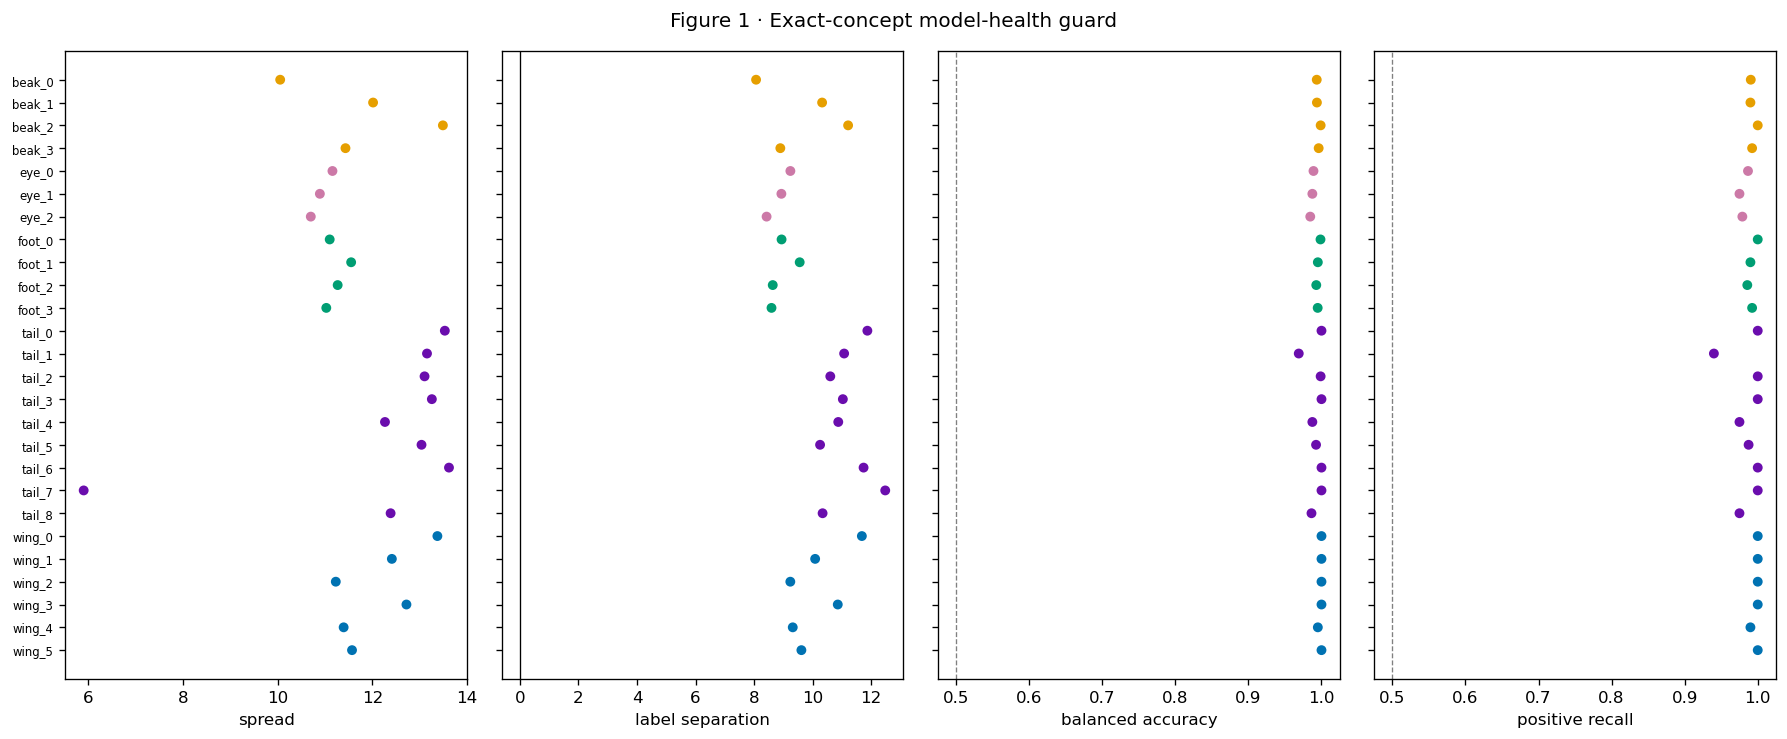

In [2]:
# ALT: Four aligned dot plots showing raw-score spread, label separation, balanced accuracy, and positive recall for every FunnyBird concept.
def balanced_accuracy(y, pred):
    y=np.asarray(y).astype(int); pred=np.asarray(pred).astype(int)
    tpr=(pred[y==1]==1).mean() if (y==1).any() else np.nan
    tnr=(pred[y==0]==0).mean() if (y==0).any() else np.nan
    return np.nanmean([tpr,tnr])

rows=[]
for j,name in enumerate(CONCEPT_NAMES):
    z=z_saved[:,j]; c=c_saved[:,j].astype(int); pred=(z>0).astype(int)
    rows.append({"concept":name,"part":CONCEPT_PART[name],
                 "spread":np.quantile(z,.95)-np.quantile(z,.05),
                 "label_separation":np.median(z[c==1])-np.median(z[c==0]),
                 "balanced_accuracy":balanced_accuracy(c,pred),
                 "positive_recall":pred[c==1].mean(),
                 "n_positive":int(c.sum()),"n_negative":int((c==0).sum())})
HEALTH=pd.DataFrame(rows).sort_values(["part","concept"])
y_true=y_saved
task_accuracy=float((y_pred_saved==y_true).mean())
concept_accuracy=float(((z_saved>0)==c_saved).mean())
display(pd.DataFrame([{"images":len(y_true),"species":len(np.unique(y_true)),
                      "task_accuracy":task_accuracy,"concept_accuracy":concept_accuracy}]).round(4))
display(HEALTH.round(3))
metrics=["spread","label_separation","balanced_accuracy","positive_recall"]
fig,axes=plt.subplots(1,4,figsize=(15,max(5,.24*len(HEALTH))),sharey=True)
y=np.arange(len(HEALTH))
for ax,m in zip(axes,metrics):
    ax.scatter(HEALTH[m],y,c=HEALTH.part.map(COLORS).fillna("#BBBBBB"),s=24)
    ax.set_xlabel(m.replace("_"," "))
    if m in ["label_separation"]: ax.axvline(0,color="black",lw=.8)
    if m in ["balanced_accuracy","positive_recall"]: ax.axvline(.5,color="gray",ls="--",lw=.8)
axes[0].set_yticks(y); axes[0].set_yticklabels(HEALTH.concept,fontsize=7)
axes[0].invert_yaxis(); fig.suptitle("Figure 1 · Exact-concept model-health guard")
plt.tight_layout(); plt.show()


    ### Plain-language reference for Figure 1

    **Plain caption.** All 26 concept outputs vary and classify their ordinary labels well, so the swap analysis is not being driven by a collapsed or unusable model.

    **Terms and how to read it.** `spread` is the 95th minus 5th percentile of raw `z`; `label separation` is the positive-label median minus the negative-label median; balanced accuracy weights positive and negative recognition equally; positive recall uses positive-labelled images as its denominator.

    **Literal values.** Across 500 held-out images, all 26 exact outputs vary: raw-z spread is 5.907-13.616, label separation is 8.069-12.483, balanced accuracy is 0.969-1.000, and positive recall is 0.940-1.000. Species accuracy is 0.992 and concept accuracy is 0.9968.

    **Interpretation.** The model is not broken or stuck. Every concept score changes across images, and the model almost always agrees with the ordinary labels. That makes the later replacement test meaningful, but it still does not tell us which pixels the model used.

**Strongest alternative explanation.** Excellent label prediction can still come from species context rather than the named part, so this figure establishes health but not grounding.

    **Discriminating test.** Use the same-image controlled replacement in Figures 3-4.

    **Verdict.** **KEEP**.

    **Proof ledger.** `ACCEPTED FOR seed-1 standard-CBM model health; no exact output is collapsed.`

    **Next question.** Is the fixed renderer intervention itself valid?


## 2 · Did the renderer change only the intended part?

**Question.** Did the renderer change only the intended part?

**Variables and prediction.** Inspect the semantic preflight and original/swap/delete/part-map examples for all five parts. A valid intervention visibly changes the target part, preserves the rest of the scene, and has nonzero target-mask pixels.

**Method.** Use artifacts from the accepted fixed-render root before reading any model response.

### Figure 2 · Did the renderer change only the intended part?

**How to read the figure.** Figure 2a is the renderer's semantic preflight: for each part it shows the
original, replacement, deletion, original part map, and replacement part
map. The named part should visibly change while body, pose, camera, and
background remain fixed. This is a pixel-operation gate; it contains no
model result.


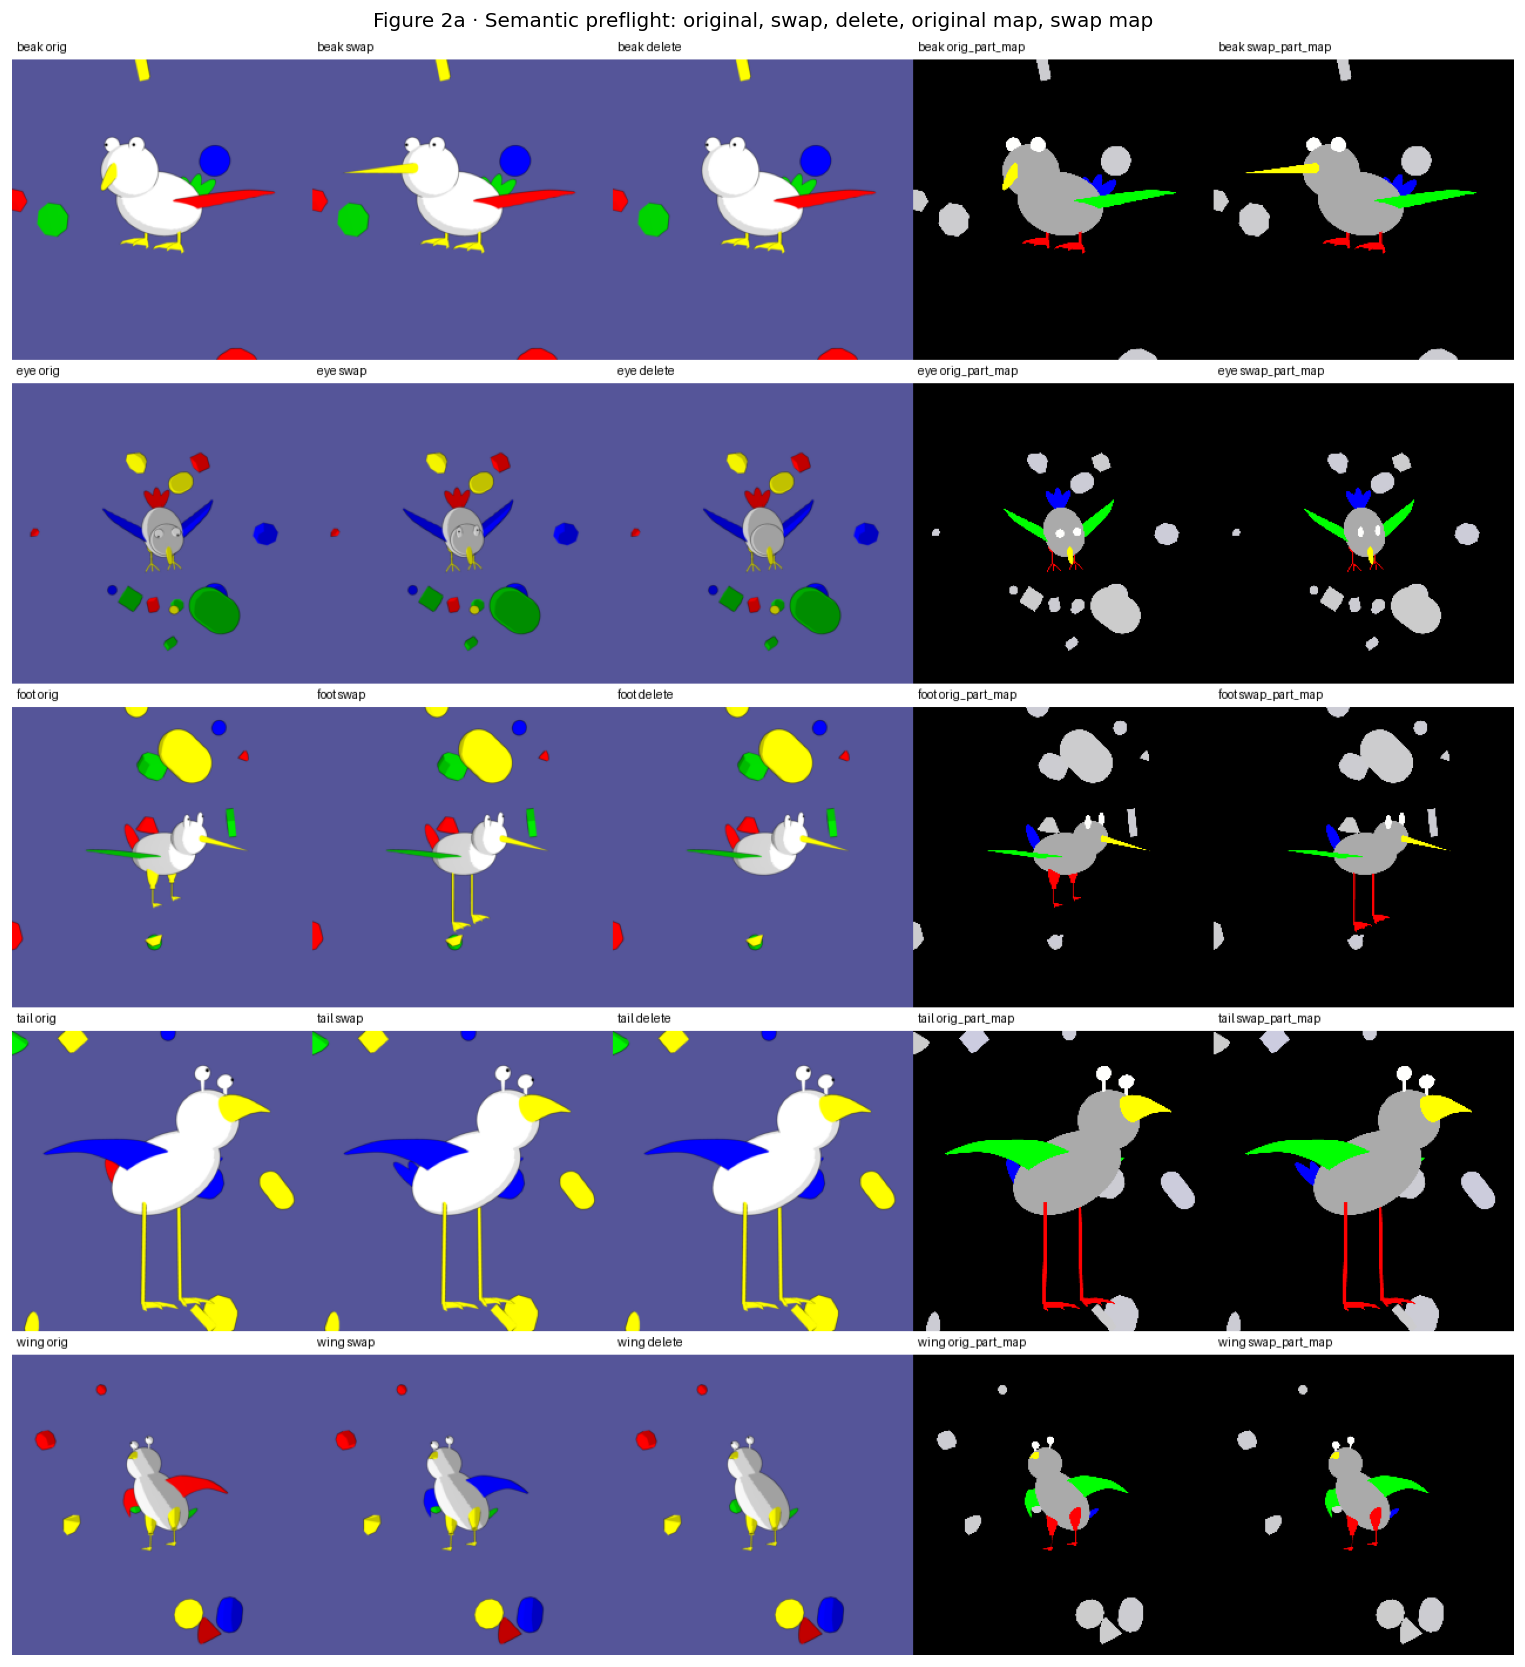

In [3]:
# ALT: FunnyBird semantic renderer preflight showing the intended one-part replacement and deletion for every part.
ROOT = SWAP.parent
preflight_candidates=[ROOT/"renderer_preflight"/"renderer_semantic_preflight.png"]
preflight=next((p for p in preflight_candidates if p.exists()),preflight_candidates[0])
example_candidates=[ROOT/"examples",CURATED/"swap_fixed_v2_attempt2"/"examples"]
examples=next((p for p in example_candidates if p.is_dir()),example_candidates[0])
from PIL import Image
if preflight.exists():
    im0=Image.open(preflight).convert("RGB")
    fig0,ax0=plt.subplots(figsize=(14,14))
    ax0.imshow(im0); ax0.axis("off")
    ax0.set_title("Figure 2a · Semantic preflight: original, swap, delete, original map, swap map")
    plt.tight_layout(); plt.show()
else:
    raise FileNotFoundError("accepted converged swap root lacks the semantic preflight sheet")


### Figure 2b · Do saved examples confirm the operation for every part?

**Question.** Does the accepted swap output contain a visually inspectable
original, replacement, deletion, and replacement-part map for tail, wing,
beak, foot, and eye?

**Variables and prediction.** Each row is one named part and each column is
one image role. A valid row changes the named part and its map while leaving
the remaining bird and scene unchanged. “Missing” is an error, not evidence.

**Method.** Select the first stored audit example by filename order for each
part. This is a complete five-part semantic check, not a hand-picked model
success/failure gallery.

**How to read the figure.** Compare columns within a row, then compare the
visible changed pixels with the highlighted replacement-part map. No axis or
color encodes a model score.


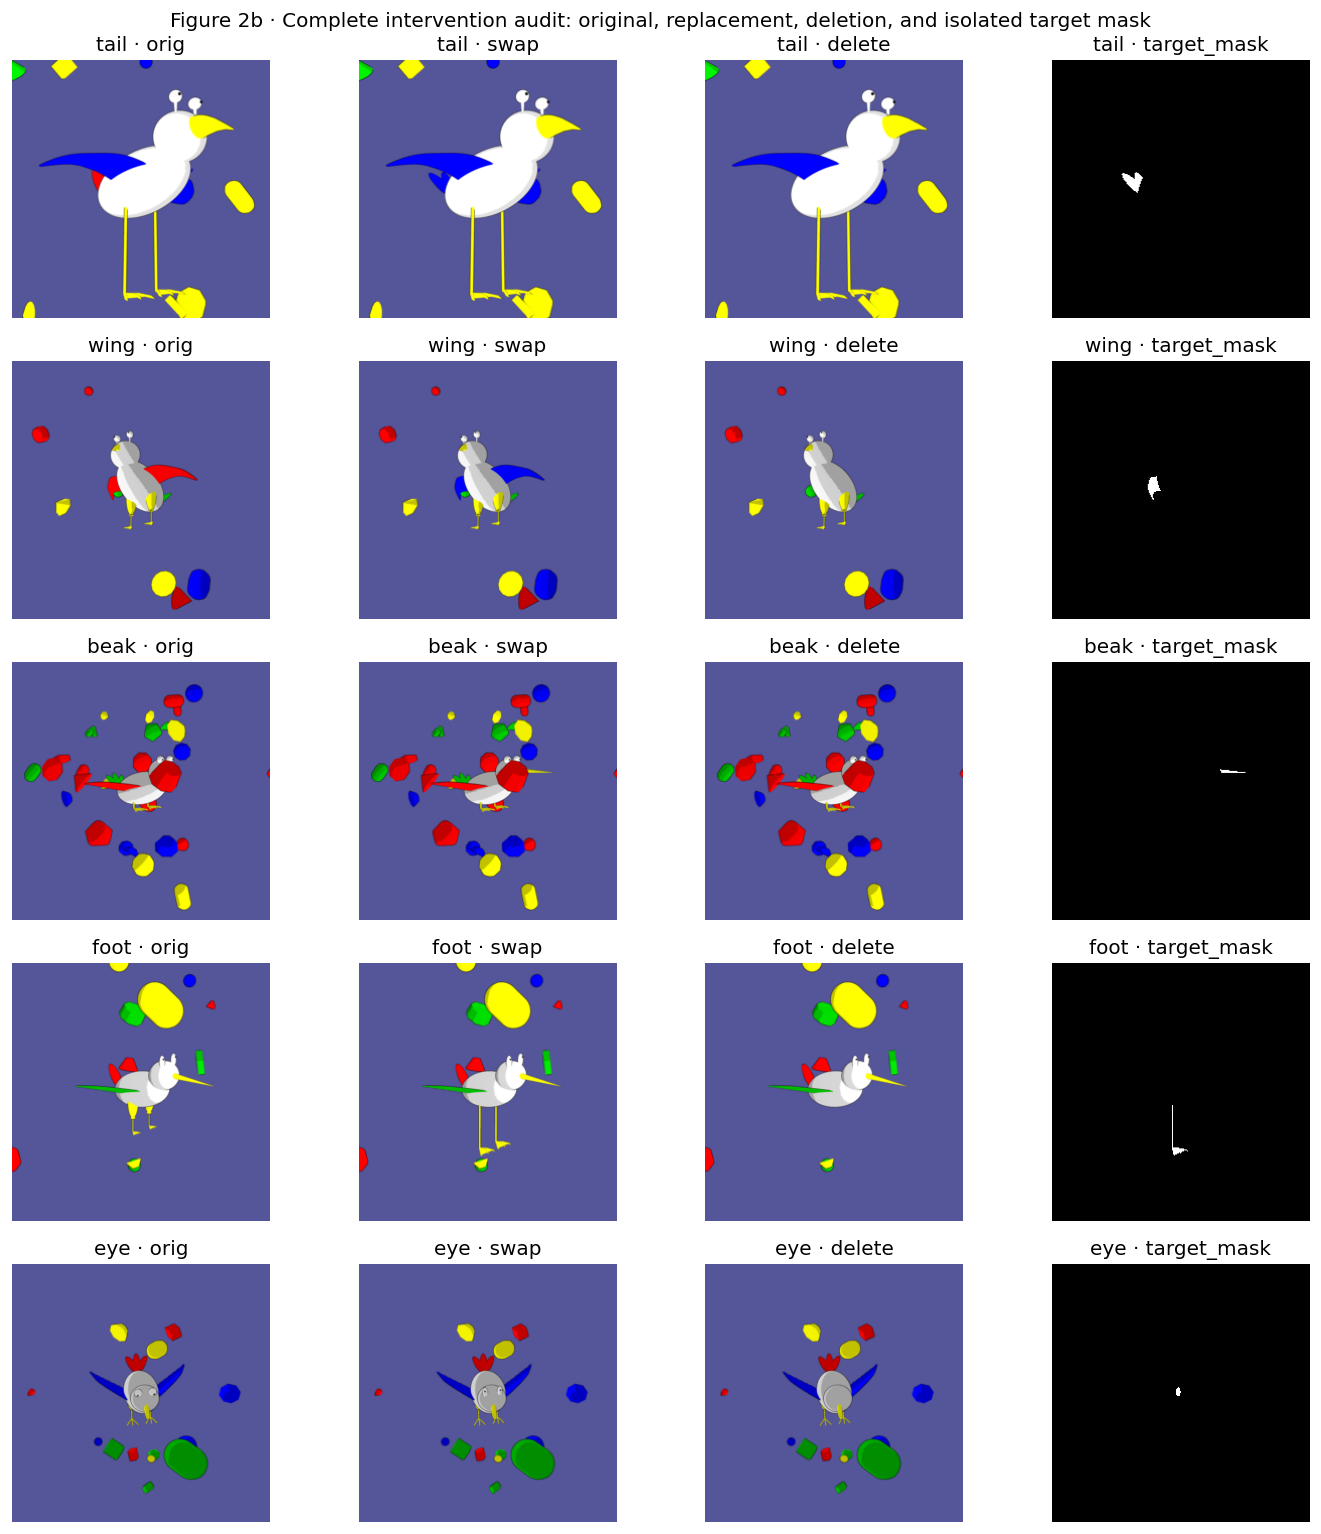

In [4]:
# ALT: Complete five-part FunnyBird intervention audit showing original, replacement, deletion, and replacement-part map.
ROOT = SWAP.parent
example_candidates=[ROOT/"examples"]
examples=next((p for p in example_candidates if p.is_dir()),example_candidates[0])
if not examples.is_dir():
    raise FileNotFoundError("accepted converged swap root lacks example images")
tags=["orig","swap","delete","target_mask"]
segmentation_colors={"beak":(255,255,0),"eye":(255,255,253),
                     "wing":(0,255,1),"foot":(255,0,1),"tail":(0,0,255)}
fig,axes=plt.subplots(len(ORDER),len(tags),figsize=(12,13))
for r,part in enumerate(ORDER):
    for c,tag in enumerate(tags):
        ax=axes[r,c]
        file_tag="swap_partmap" if tag=="target_mask" else tag
        files=sorted(examples.glob(f"{part}_*_{file_tag}.png"))
        if files and tag=="target_mask":
            segmentation=np.asarray(Image.open(files[0]).convert("RGB"))
            target=np.all(segmentation==np.asarray(segmentation_colors[part]),axis=2)
            ax.imshow(target,cmap="gray",vmin=0,vmax=1)
        elif files:
            ax.imshow(Image.open(files[0]).convert("RGB"))
        else:
            ax.text(.5,.5,"missing",ha="center",va="center")
        ax.set_title(f"{part} · {tag}"); ax.axis("off")
fig.suptitle("Figure 2b · Complete intervention audit: original, replacement, deletion, and isolated target mask")
plt.tight_layout(); plt.show()


    ### Plain-language reference for Figure 2

    **Plain caption.** The renderer changes the named part while preserving the rest of the bird and scene, which makes the immediate within-image response causally interpretable.

    **Terms and how to read it.** Rows are named parts; columns are original, replacement, deletion, and part-map roles. The colors are image pixels or renderer masks, not model scores.

    **Literal values.** For tail, wing, beak, foot, and eye, the displayed replacement and deletion alter the named part while the body, pose, camera, and background remain fixed; the target part map contains the changed region.

    **Interpretation.** The pictures and the full-file checks agree that the experiment changes the named part rather than silently replacing the whole bird or scene. We can therefore attribute the immediate score change to the inserted part pixels.

**Strongest alternative explanation.** A few photographs alone would not certify the full cache.

    **Discriminating test.** Retain the semantic preflight plus the accepted fixed-render hash/diversity validation across all evaluated models and render IDs.

    **Verdict.** **KEEP**.

    **Proof ledger.** `ACCEPTED FOR the validated FunnyBird fixed-render intervention.`

    **Next question.** Do those inserted pixels move the raw concept comparison toward the donor?


## 3 · Did the inserted pixels move the comparison toward the donor?

**Question.** Did the inserted pixels move the comparison toward the donor?

**Variables and prediction.** `response_delta = (z_donor-z_source)_cf - (z_donor-z_source)_orig`. Legacy CSV columns named `z_*` contain these post-head raw logits. Values above zero mean that replacement pixels moved the model toward the donor concept.

**Method.** Plot the complete distribution for every part and report the positive-response rate.

### Figure 3 · Did the inserted pixels move the comparison toward the donor?

**How to read the figure.** Panel A puts part on the x-axis and `response_delta` in raw-logit units on the
y-axis. The box spans the 25th--75th percentiles, the orange line is the
median, and whiskers are the 5th--95th percentiles; outliers are omitted only
from drawing. Zero means no donorward change and values above zero mean the
donor gained relative to the old source. Panel B reports the fraction above
zero, with `n` printed over each bar. Colors identify parts using the shared
FunnyBird palette. This measures response size, not whether the donor wins.
Example: a margin change from -20 before replacement to -5 afterward gives
`response_delta=+15`, although the final margin remains negative.


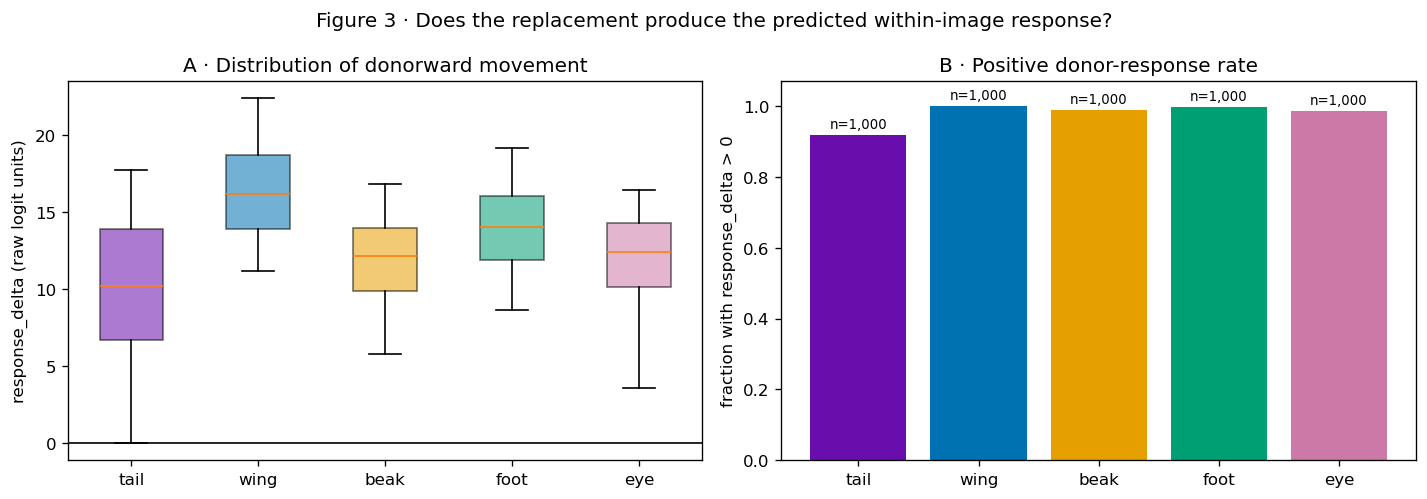

,positive_response_rate
part,
tail,0.919
wing,1.000
beak,0.989
foot,0.997
eye,0.986


In [5]:
# ALT: FunnyBird response-delta distributions and positive donor-response rates for all five parts.
fig,axes=plt.subplots(1,2,figsize=(12,4.2))
vals=[S.loc[S.part==p,"response_delta"].dropna() for p in ORDER]
bp=axes[0].boxplot(vals,tick_labels=ORDER,showfliers=False,whis=(5,95),patch_artist=True)
for box,p in zip(bp["boxes"],ORDER): box.set_facecolor(COLORS[p]); box.set_alpha(.55)
axes[0].axhline(0,color="black",lw=1); axes[0].set_ylabel("response_delta (raw logit units)")
axes[0].set_title("A · Distribution of donorward movement")
rate=S.groupby("part").response_delta.apply(lambda x:(x>0).mean()).reindex(ORDER)
axes[1].bar(rate.index,rate.values,color=[COLORS[p] for p in rate.index])
axes[1].set_ylim(0,1.07)
axes[1].set_ylabel("fraction with response_delta > 0"); axes[1].set_title("B · Positive donor-response rate")
counts=S.groupby("part").size().reindex(ORDER)
for x,(p,v) in enumerate(rate.items()): axes[1].text(x,min(v+.018,1.025),f"n={counts[p]:,}",ha="center",fontsize=8)
fig.suptitle("Figure 3 · Does the replacement produce the predicted within-image response?")
plt.tight_layout(); plt.show(); display(rate.rename("positive_response_rate").to_frame().round(3))


    ### Plain-language reference for Figure 3

    **Plain caption.** Inserted part pixels move the donor-versus-source comparison toward the donor for nearly every swap, although this does not yet say which concept wins.

    **Terms and how to read it.** `response_delta=m_cf-m_orig` is measured in raw-logit units. Above zero means donorward movement. The box shows the middle 50%, whiskers show the 5th--95th percentiles, and each rate uses all 1,000 swaps for that part.

    **Literal values.** The complete response distributions are donorward for nearly every swap. Positive-response rates are tail 0.919, wing 1.000, beak 0.989, foot 0.997, and eye 0.986, with 1,000 swaps per part.

    **Interpretation.** The model nearly always notices the new part: its answer moves toward the inserted value in at least 91.9% of swaps for every part. The next question is whether that movement is large enough to change the final answer.

**Strongest alternative explanation.** A positive movement alone does not say that the inserted donor finishes above the old source.

    **Discriminating test.** Inspect the final donor-minus-source margin jointly with response_delta.

    **Verdict.** **KEEP**.

    **Proof ledger.** `ACCEPTED FOR a causal within-image response to the inserted part pixels in all five parts. Tail, beak, and eye have smaller typical movement than wing and foot; tail is not the mechanism and is not the only comparatively weak response.`

    **Next question.** Did the parts start equally far behind, and did donor rise versus source release contribute differently?


## 3b — Where did each part start, and which score changed after replacement?

**Question.** Does a part finish poorly because its donor began far below
the source, because the donor rose too little, because the removed source
fell too little, or because several of these occurred together?

**Variables and exact identity.** For every swap:

`m_orig = z_donor,orig - z_source,orig`

`donor_gain = z_donor,cf - z_donor,orig`

`source_decrease = z_source,orig - z_source,cf`

`response_delta = donor_gain + source_decrease`

`m_cf = m_orig + response_delta`

**Score scale.** Every quantity here uses the post-head raw logit
`z=q(h)`, which is unbounded. This standard CBM has no MCBM gamma penalty
and no `±3` target. Notebook 03 applies the soft `±3` target to internal
`h`, not to the plotted `z`.

`m_orig` is the starting preference on the unchanged original image. It
is **not** a pure context measurement because the source part is still
visible there. Species/body context is tested separately later.

Example: the donor starts 20 units below the source, then rises by 9 while
the old source falls by 6. Total donorward response is 15, so the final
margin is `-20+9+6=-5`: the swap helped, but the source still wins.

**Method.** Average each raw-logit quantity over all 1,000 validated swaps
for each part, including both directions. Verify the exact row-wise
identity before displaying any mean.

### Figure 3b — Starting preference, donor rise, source release, response, and final result

**How to read the figure.** All panels use the same raw-logit y-axis and
part colors. Panel A below zero means the future donor starts behind.
Panels B and C above zero are the two ways replacement helps. Panel D is
their sum. Panel E above zero means the donor finally wins. Part names
identify observed outcomes, not mechanisms.


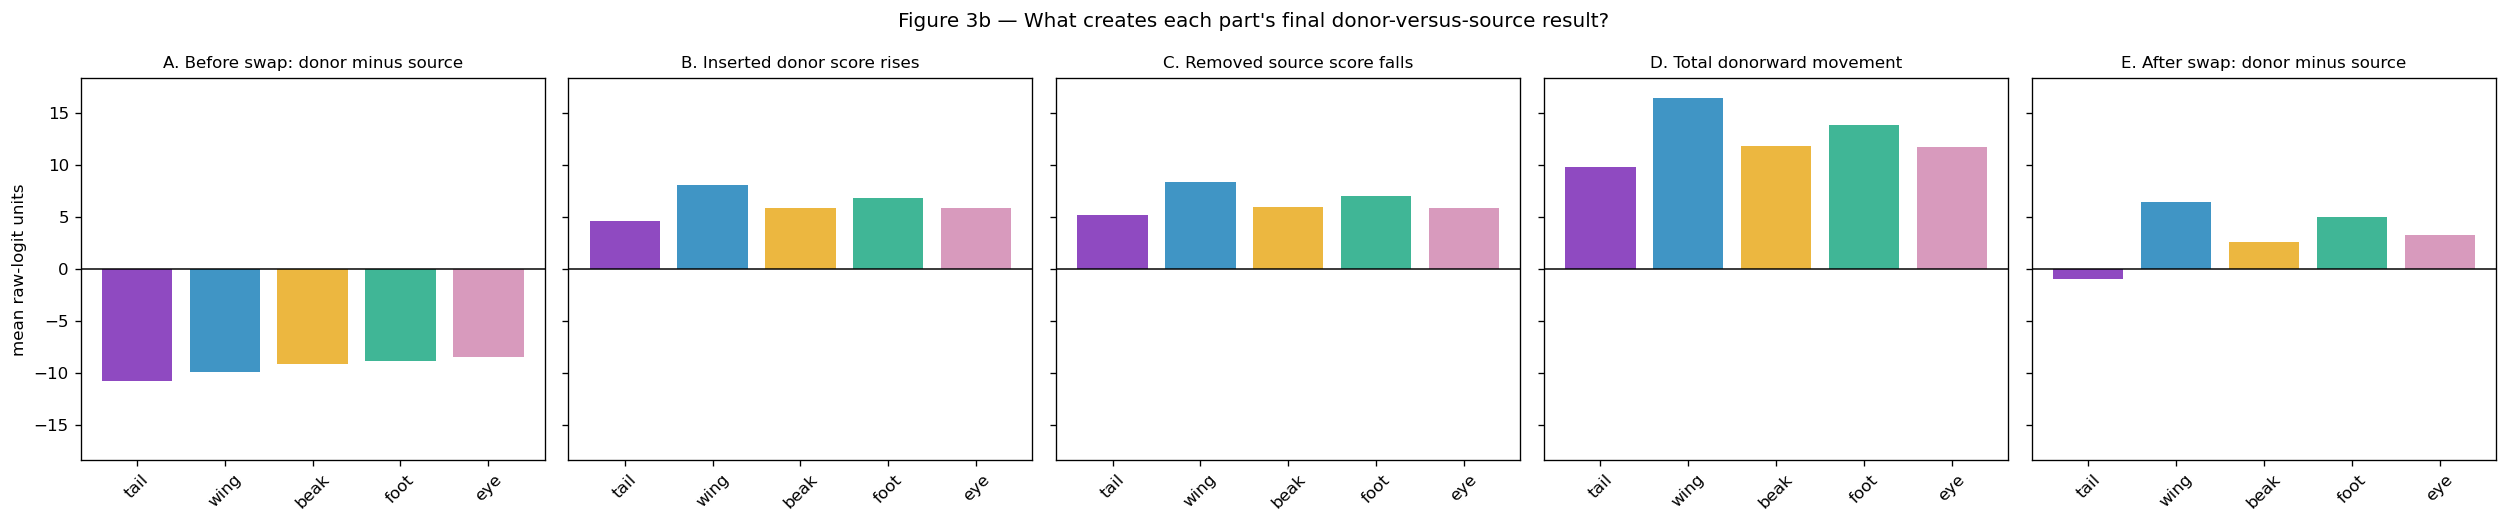

,m_orig,donor_gain,source_decrease,response_delta,m_cf
part,,,,,
tail,-10.756,4.599,5.201,9.800,-0.956
wing,-9.914,8.029,8.361,16.390,6.476
beak,-9.167,5.842,5.936,11.778,2.611
foot,-8.847,6.804,7.027,13.831,4.984
eye,-8.481,5.875,5.874,11.749,3.268


maximum row-wise decomposition error: 1.7763568394002505e-15


In [6]:
# ALT: Standard FunnyBird CBM starting margin, donor-score gain, removed-source decrease, total response, and final margin for all five parts.
component_columns=["m_orig","donor_gain","source_decrease","response_delta","m_cf"]
component_means=S.groupby("part")[component_columns].mean().reindex(ORDER)
decomposition_error=np.max(np.abs(S.m_cf-(S.m_orig+S.donor_gain+S.source_decrease)))
if decomposition_error>1e-8: raise RuntimeError(f"decomposition error {decomposition_error}")
titles=[("m_orig","A. Before swap: donor minus source"),
        ("donor_gain","B. Inserted donor score rises"),
        ("source_decrease","C. Removed source score falls"),
        ("response_delta","D. Total donorward movement"),
        ("m_cf","E. After swap: donor minus source")]
lim=float(np.nanmax(np.abs(component_means.values)))*1.12
fig,axes=plt.subplots(1,5,figsize=(21,4.4),sharey=True)
for ax,(column,title) in zip(axes,titles):
    values=component_means[column]
    ax.bar(ORDER,values.values,color=[COLORS[p] for p in ORDER],alpha=.75)
    ax.axhline(0,color="black",lw=.9); ax.set_title(title,fontsize=10)
    ax.tick_params(axis="x",rotation=45); ax.set_ylim(-lim,lim)
axes[0].set_ylabel("mean raw-logit units")
fig.suptitle("Figure 3b — What creates each part's final donor-versus-source result?")
plt.tight_layout(); plt.show(); display(component_means.round(3))
print("maximum row-wise decomposition error:",decomposition_error)


### Plain-language reference for Figure 3b

**Plain caption.** The final donor-versus-source result combines a
starting preference for the source with the donor's rise and the
source's fall after replacement.

**Terms.** Starting margin is donor score minus source score before
replacement. Inserted donor score rises is the increase in the donor
concept's score. Removed source score falls is the decrease in the old
source concept's score. Total donorward movement is donor rise plus
source decrease. Final margin is starting margin plus total movement. A
negative final margin means the old source concept remains higher. All
five panels use mean raw-logit units over 1,000 swaps per part.

**Literal mean values.**

| Part | Starting margin | Donorward movement | Final margin |
|---|---:|---:|---:|
| tail | `-10.756` | `+9.800` | `-0.956` |
| wing | `-9.914` | `+16.390` | `+6.476` |
| beak | `-9.167` | `+11.778` | `+2.611` |
| foot | `-8.847` | `+13.831` | `+4.984` |
| eye | `-8.481` | `+11.749` | `+3.268` |

The row-wise arithmetic identity closes to numerical error below
`1.8e-15`. Tail's donor rise is `4.599` and old-source decrease is
`5.201`, both the smallest part means.

**Interpretation.** Every part starts with a strong source preference.
Wing, beak, foot, and eye usually produce enough movement to overcome
it. Tail produces a large response too, but its average response is
insufficient to erase the starting preference. Tail does not mainly
fail because it began uniquely far behind; its total correction is
smaller.

**Alternative.** Tail could be smaller, hidden more often, harder to
distinguish exactly, or more strongly associated with species context.
Means can also hide direction and exact-value asymmetry, and the original
margin still contains genuine source-part pixels.

**Discriminating test.** Separate direction, visibility, exact values,
and source-species organization in the following figures.

**Verdict.** **KEEP**.

**Proof ledger.** The competition producing the final margin is
separated arithmetically. The causes of the starting preference and
unequal replacement response remain unresolved.

**Next question.** How often does the donor actually finish higher?


## 4 · After responding, does the donor finish above the old source?

**Question.** After responding, does the donor finish above the old source?

**Variables and prediction.** The final margin is `m_cf=z_donor,cf-z_source,cf`. The primary event is `response_delta>0` with `m_cf<0`. A lower-right quadrant point means the inserted pixels had an effect but the old source still wins.

**Method.** Show final-margin distributions and the joint response/margin plane for every part.

### Figure 4 · After responding, does the donor finish above the old source?

**How to read the figure.** In the margin panel, zero separates donor wins (`m_cf>0`) from old-source wins
(`m_cf<0`). In the quadrant panel, x is donorward movement and y is the final
donor-minus-source score. The lower-right quadrant is the controlled
backwash predicate `response_delta>0 and m_cf<0`: the new pixels moved the
answer toward the donor, but the old source still finished higher. Boxes and colors use the Figure 3 definitions;
translucent points are individual swaps and the legend maps color to part.
Example: `m_cf=-5` means the old source finishes five raw-logit units above
the donor.


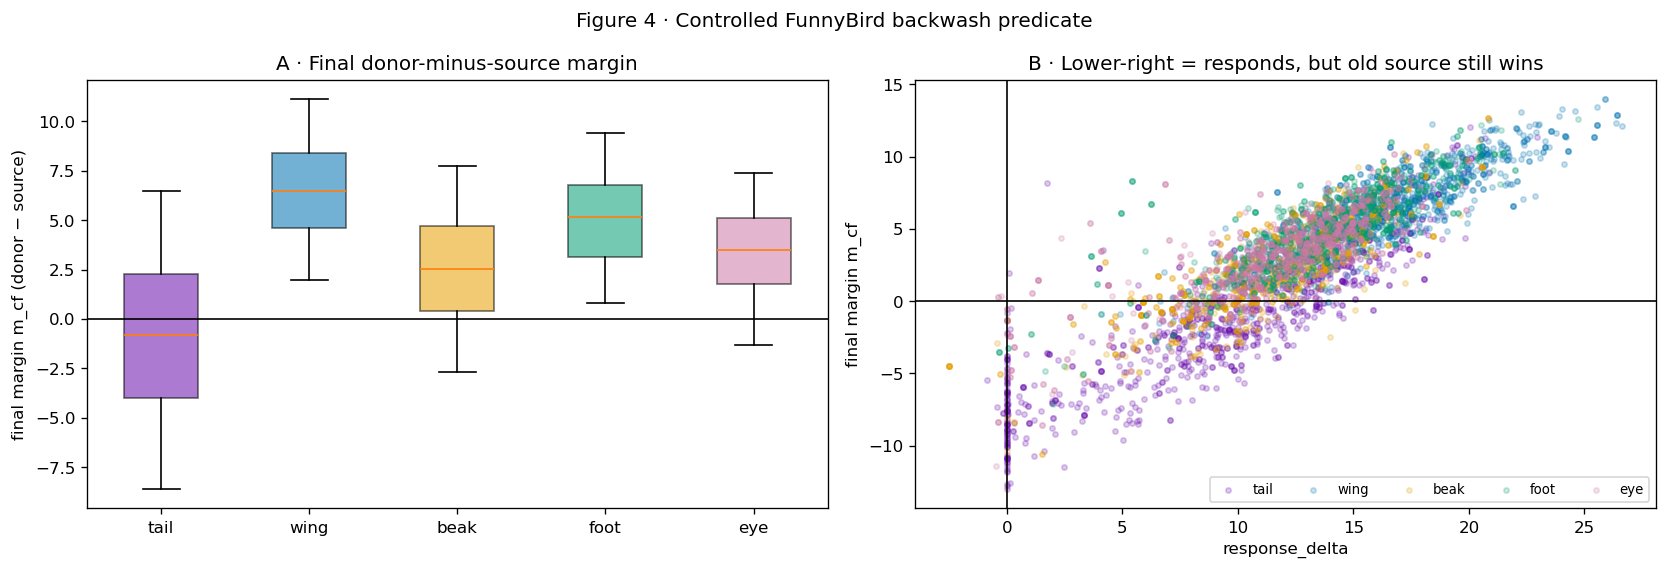

,n,median_response,median_final_margin,positive_response_rate,responded_but_source_wins_rate
part,,,,,
tail,1000,10.226,-0.819,0.919,0.502
wing,1000,16.183,6.483,1.000,0.019
beak,1000,12.170,2.551,0.989,0.200
foot,1000,14.058,5.158,0.997,0.032
eye,1000,12.388,3.511,0.986,0.089


In [7]:
# ALT: Final donor-minus-source margin distributions and joint response-delta versus final-margin plot for all FunnyBird parts.
fig,axes=plt.subplots(1,2,figsize=(14,4.8))
vals=[S.loc[S.part==p,"margin"].dropna() for p in ORDER]
bp=axes[0].boxplot(vals,tick_labels=ORDER,showfliers=False,whis=(5,95),patch_artist=True)
for box,p in zip(bp["boxes"],ORDER): box.set_facecolor(COLORS[p]); box.set_alpha(.55)
axes[0].axhline(0,color="black",lw=1); axes[0].set_ylabel("final margin m_cf (donor − source)")
axes[0].set_title("A · Final donor-minus-source margin")
for p in ORDER:
    d=S[S.part==p]
    axes[1].scatter(d.response_delta,d.margin,s=10,alpha=.22,color=COLORS[p],label=p)
axes[1].axvline(0,color="black",lw=1); axes[1].axhline(0,color="black",lw=1)
axes[1].set_xlabel("response_delta"); axes[1].set_ylabel("final margin m_cf")
axes[1].set_title("B · Lower-right = responds, but old source still wins")
axes[1].legend(ncol=5,fontsize=8)
fig.suptitle("Figure 4 · Controlled FunnyBird backwash predicate")
plt.tight_layout(); plt.show()
summary=S.groupby("part").agg(n=("margin","size"),median_response=("response_delta","median"),
    median_final_margin=("margin","median"),positive_response_rate=("response_delta",lambda x:(x>0).mean()),
    responded_but_source_wins_rate=("responded_but_source_wins","mean")).reindex(ORDER)
display(summary.round(3))


    ### Plain-language reference for Figure 4

    **Plain caption.** Controlled backwash is graded: the model responds to the new pixels but the old source answer still wins most often for tail and less often for every other part.

    **Terms and how to read it.** `m_cf=z_donor,cf-z_source,cf`. A negative final margin means the old source remains higher. The controlled event requires both `response_delta>0` and `m_cf<0` on the same row.

    **Literal values.** Median final margins are tail -0.819, wing 6.483, beak 2.551, foot 5.158, and eye 3.511 raw-logit units. On the same 1,000 swaps per part, the donorward-response-but-source-wins rates are 0.502, 0.019, 0.200, 0.032, and 0.089, respectively.

    **Interpretation.** Yes, backwash occurs. Tail is the clearest case: in about half the tail replacements, the model reacts in the correct direction but still favors the tail value belonging to the original bird. The same event also occurs less often for beak, eye, foot, and wing.

**Strongest alternative explanation.** Starting preference, swap direction, target visibility, exact value difficulty, and source species could organize the unequal rates.

    **Discriminating test.** Test those alternatives separately in Figures 5-9 without changing the event definition.

    **Verdict.** **KEEP**.

    **Proof ledger.** `ACCEPTED FOR the seed-1 controlled FunnyBird backwash predicate across a graded part ordering: strongest for tail, beak, and eye, with minority events also in wing and foot. This is not a tail-specific mechanism claim.`

    **Next question.** Can swap direction create the pooled pattern?


## 4b — How often does the donor win, help but still lose, or fail to move donorward?

Every validated swap is placed into exactly one outcome:

1. `m_cf > 0`: the donor concept finishes higher;
2. `m_cf <= 0 and response_delta > 0`: the new pixels help, but the old
   source concept remains higher;
3. `m_cf <= 0 and response_delta <= 0`: the source remains higher and the
   replacement does not move the comparison toward the donor.

These fractions sum to one for every part. Thus Figure 4's controlled-
backwash rate is not the donor-win rate.

Example: if 20 of 100 swaps end donor-positive, 50 move donorward but
remain source-negative, and 30 do not move donorward, the three displayed
fractions are 0.20, 0.50, and 0.30. The denominator is all 100 swaps.

### Figure 4b — Three mutually exclusive outcomes for every part

**How to read the figure.** Every panel contains all five parts and uses a
fraction from zero to one. Higher is desirable only in Panel A. Panel B
is the controlled backwash event. Panel C is a different failure: no
positive response. Both swap directions are included. Bar colors use the
shared part palette defined at the start of the notebook.


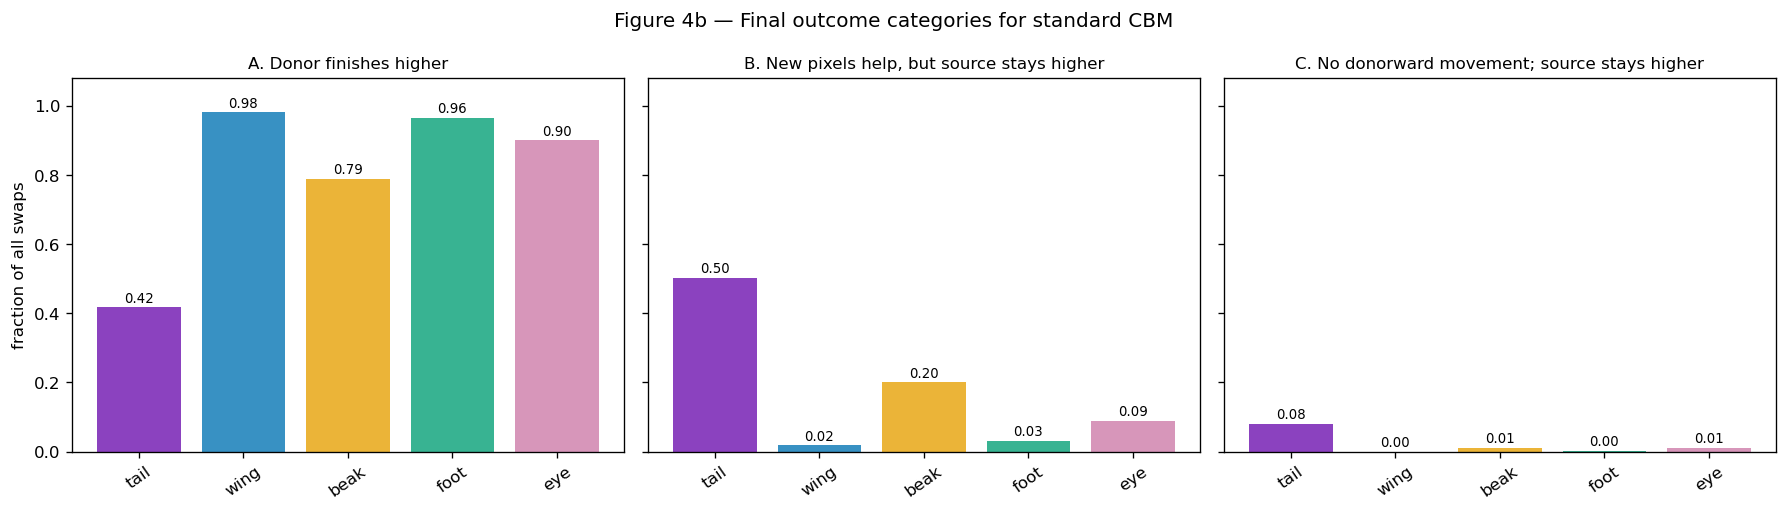

,donor_wins,helped_but_source_wins,no_donorward_move_and_source_wins
tail,0.417,0.502,0.081
wing,0.981,0.019,0.000
beak,0.789,0.200,0.011
foot,0.965,0.032,0.003
eye,0.900,0.089,0.011


In [8]:
# ALT: Standard FunnyBird CBM donor-win, donorward-but-source-still-wins, and no-donorward-movement fractions for all five parts.
outcomes=pd.DataFrame(index=ORDER,dtype=float)
outcomes["donor_wins"]=(S.m_cf>0).groupby(S.part).mean().reindex(ORDER)
outcomes["helped_but_source_wins"]=((S.m_cf<=0)&(S.response_delta>0)).groupby(S.part).mean().reindex(ORDER)
outcomes["no_donorward_move_and_source_wins"]=((S.m_cf<=0)&(S.response_delta<=0)).groupby(S.part).mean().reindex(ORDER)
if not np.allclose(outcomes.sum(axis=1).values,1):
    raise RuntimeError("three outcome fractions do not sum to one")
panels=[("donor_wins","A. Donor finishes higher"),
        ("helped_but_source_wins","B. New pixels help, but source stays higher"),
        ("no_donorward_move_and_source_wins","C. No donorward movement; source stays higher")]
fig,axes=plt.subplots(1,3,figsize=(15,4.3),sharey=True)
for ax,(column,title) in zip(axes,panels):
    values=outcomes[column]
    ax.bar(ORDER,values.values,color=[COLORS[p] for p in ORDER],alpha=.78)
    ax.set_title(title,fontsize=10); ax.set_ylim(0,1.08); ax.tick_params(axis="x",rotation=35)
    for x,value in enumerate(values): ax.text(x,value+.015,f"{value:.2f}",ha="center",fontsize=8)
axes[0].set_ylabel("fraction of all swaps")
fig.suptitle("Figure 4b — Final outcome categories for standard CBM")
plt.tight_layout(); plt.show(); display(outcomes.round(3))


### Plain-language reference for Figure 4b

**Plain caption.** Every replacement is assigned to exactly one final
outcome, separating successful donor wins from insufficient donorward
corrections and from complete failures to move donorward.

**Terms and denominator.** Donor wins means `m_cf>0`. Helped but source
wins means `response_delta>0` and `m_cf<=0`, the controlled backwash
event. No donorward move means both quantities are non-positive. Each
fraction uses all 1,000 swaps for that part, and the three bars sum to one.

**Literal values.** Donor-win/helped-but-source-wins/no-donorward-move
fractions are tail `0.417/0.502/0.081`, wing `0.981/0.019/0.000`, beak
`0.789/0.200/0.011`, foot `0.965/0.032/0.003`, and eye
`0.900/0.089/0.011`.

**Interpretation.** Tail usually notices the replacement: only 8.1% of
tail swaps fail to move toward the donor. The larger problem is that the
correction is insufficient—50.2% move the right way but retain the old
answer. Most beak and eye failures have the same form.

**Alternative.** A positive response may be tiny, and pooled outcomes
may hide direction or exact-value asymmetry.

**Discriminating test.** Retain Figure 3b's response magnitudes and next
separate directions and exact donor values.

**Verdict.** **KEEP**.

**Proof ledger.** The controlled event is distinguished from a model
that simply did not react to the inserted pixels.

**Next question.** Does the pattern occur in both swap directions?


## 5 · Could opposite swap directions create the result?

**Question.** Could opposite swap directions create the result?

**Variables and prediction.** Compare forward and backward rates of `response_delta>0 and final margin<0`, together with median margins. A genuine part pattern should appear in both directions rather than cancel when pooled.

**Method.** Keep directions separate and show their denominators.

### Figure 5 · Could opposite swap directions create the result?

**How to read the figure.** Each part has separate forward (`fwd`) and backward (`bwd`) replacement
estimates, shown as unconnected circles and squares. The rate is
the fraction of rows in the lower-right quadrant from Figure 4; the printed
denominator is the number of swaps. Similar values in both directions argue
against a pooled average hiding opposite effects. A rate of 0.60 means 60%
of swaps in that direction satisfy both `response_delta>0` and `m_cf<0`.


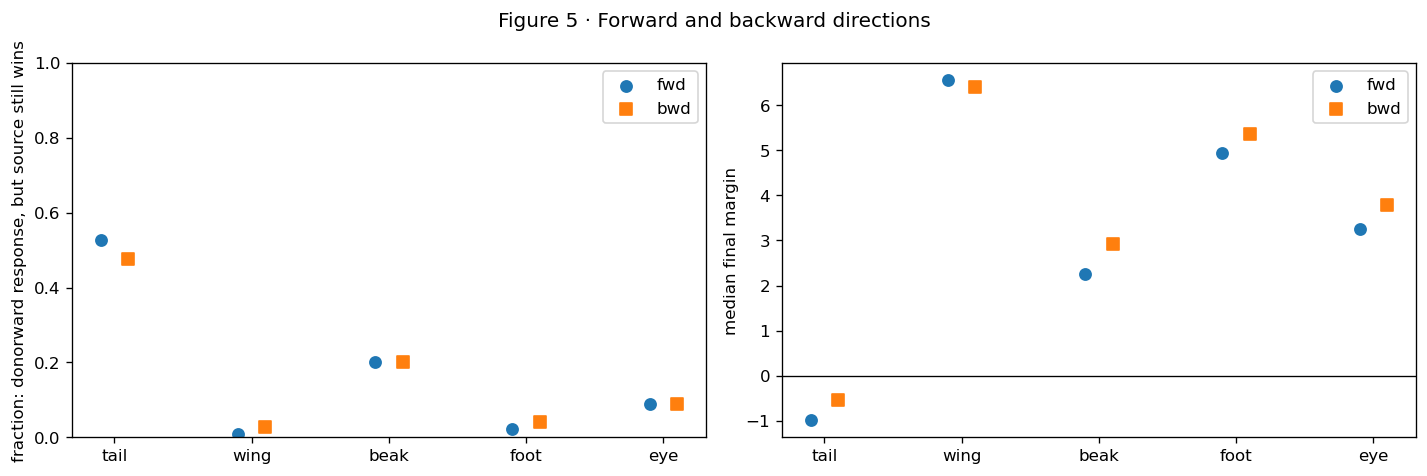

,part,direction,n,median_margin,responded_but_source_wins_rate
0,beak,bwd,500,2.915,0.200
1,beak,fwd,500,2.252,0.200
2,eye,bwd,500,3.782,0.088
3,eye,fwd,500,3.256,0.090
4,foot,bwd,500,5.368,0.042
5,foot,fwd,500,4.948,0.022
6,tail,bwd,500,-0.545,0.476
7,tail,fwd,500,-0.992,0.528
8,wing,bwd,500,6.410,0.028
9,wing,fwd,500,6.561,0.010


In [9]:
# ALT: Forward and backward FunnyBird rates where the donor changes the margin but the old source remains larger, alongside final margins for every part.
D=(S.groupby(["part","direction"]).agg(n=("margin","size"),median_margin=("margin","median"),
     responded_but_source_wins_rate=("responded_but_source_wins","mean")).reset_index())
fig,axes=plt.subplots(1,2,figsize=(12,4))
x=np.arange(len(ORDER))
for direction,marker,offset in [("fwd","o",-.10),("bwd","s",.10)]:
    d=D[D.direction==direction].set_index("part").reindex(ORDER)
    axes[0].scatter(x+offset,d.responded_but_source_wins_rate,marker=marker,label=direction,s=45)
    axes[1].scatter(x+offset,d.median_margin,marker=marker,label=direction,s=45)
for ax in axes: ax.set_xticks(x,ORDER)
axes[0].set_ylim(0,1); axes[0].set_ylabel("fraction: donorward response, but source still wins")
axes[1].axhline(0,color="black",lw=.8); axes[1].set_ylabel("median final margin")
axes[0].legend(); axes[1].legend(); fig.suptitle("Figure 5 · Forward and backward directions")
plt.tight_layout(); plt.show(); display(D.round(3))


    ### Plain-language reference for Figure 5

    **Plain caption.** The part ordering appears in both replacement directions rather than being created by pooling one easy and one difficult direction.

    **Terms and how to read it.** Forward and backward name the two replacement directions. Every displayed rate is controlled-event rows divided by the 500 swaps in that direction; markers are not connected because direction is categorical.

    **Literal values.** Forward and backward results preserve the ordering. Tail rates are 0.528 and 0.476; beak is 0.200 in both; eye is 0.090 and 0.088; foot is 0.022 and 0.042; wing is 0.010 and 0.028. Each direction has 500 swaps.

    **Interpretation.** The ordering is not created by averaging an easy direction with a hard direction. Replacing A with B and replacing B with A give similar part rankings, especially for tail, beak, and eye.

**Strongest alternative explanation.** Individual source/donor value pairs can still be asymmetric even when pooled directions agree.

    **Discriminating test.** Inspect every exact inserted value and both direction-specific denominators.

    **Verdict.** **KEEP**.

    **Proof ledger.** `ACCEPTED FOR excluding opposite-direction cancellation as the main explanation.`

    **Next question.** How does exact target visibility change the event?


## 6 · How much of the result is associated with target visibility?

**Question.** How much of the result is associated with target visibility?

**Variables and prediction.** Use `pixel_count_cf` from the exact swapped-part map and the same final-margin and `response_delta>0, margin<0` definition. If visibility is sufficient, highly visible replacements should remove the part gap; a remaining gap requires another explanation.

**Method.** Use declared bins and print the number of swap rows in every bin.

### Figure 6 · How much of the result is associated with target visibility?

**How to read the figure.** The x-axis bins swaps by the number of visible pixels in the inserted target
part. One panel shows median final raw-logit margin; the other shows the
responded-but-source-wins fraction. If visibility were the whole explanation,
sufficiently large visible parts should make margins positive and drive that
fraction near zero for every part. Point color identifies part; the table
gives the exact denominator for every nonempty bin. The companion visible-only
summary uses the same rule for all parts: `pixel_count_cf > 0`. A median
margin of +3 means the donor finishes three raw-logit units above the source.


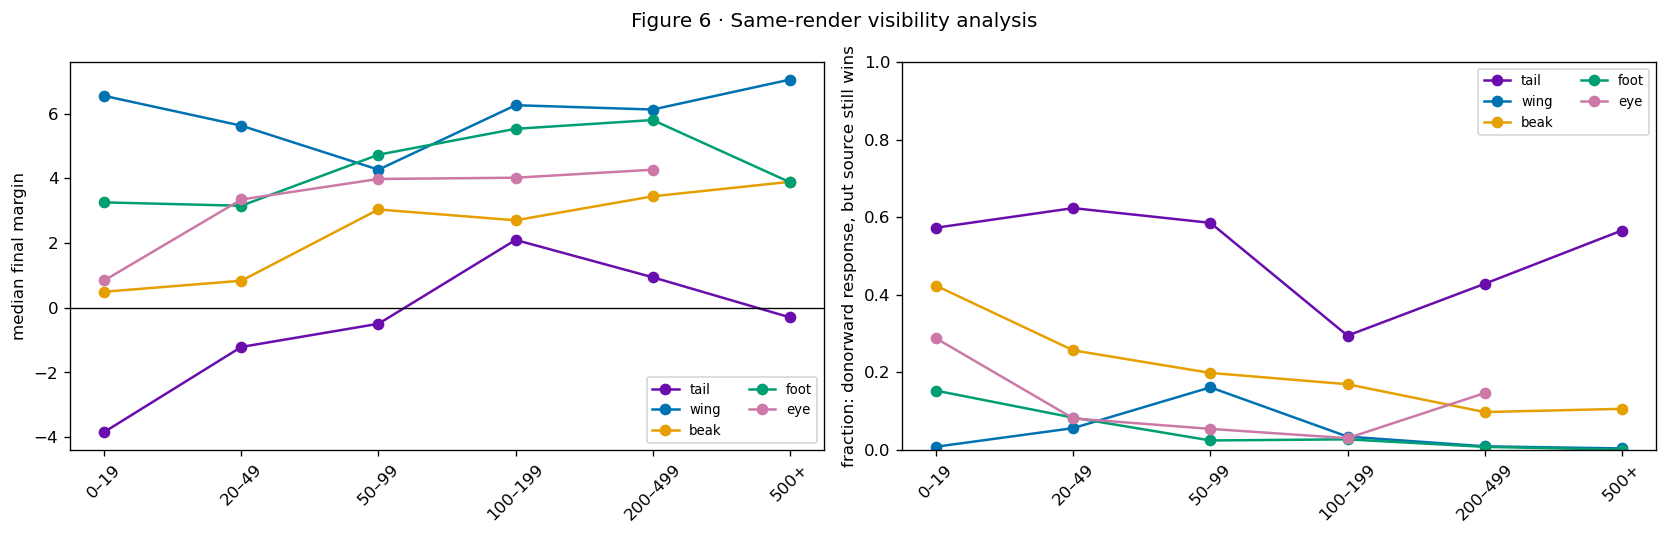

,part,visibility_bin,n,median_margin,responded_but_source_wins_rate
0,beak,0–19,123,0.493,0.423
1,beak,20–49,164,0.834,0.256
2,beak,50–99,192,3.036,0.198
3,beak,100–199,237,2.702,0.169
4,beak,200–499,227,3.442,0.097
5,beak,500+,57,3.889,0.105
6,eye,0–19,115,0.843,0.287
7,eye,20–49,335,3.344,0.081
8,eye,50–99,299,3.979,0.054
9,eye,100–199,203,4.017,0.030


,n_visible_rows,median_margin,responded_but_source_wins_rate
part,,,
tail,813,0.057,0.496
wing,909,6.475,0.021
beak,995,2.566,0.200
foot,998,5.158,0.032
eye,967,3.569,0.074


In [10]:
# ALT: FunnyBird final margin and responded-but-source-still-wins rate across exact swapped-part visibility bins for all parts.
if "pixel_count_cf" not in S: raise RuntimeError("fixed swap CSV lacks pixel_count_cf")
bins=[0,20,50,100,200,500,np.inf]; labels=["0–19","20–49","50–99","100–199","200–499","500+"]
V=S.copy(); V["visibility_bin"]=pd.cut(V.pixel_count_cf,bins=bins,labels=labels,right=False)
T=V.groupby(["part","visibility_bin"],observed=True).agg(
    n=("margin","size"),median_margin=("margin","median"),responded_but_source_wins_rate=("responded_but_source_wins","mean")).reset_index()
fig,axes=plt.subplots(1,2,figsize=(14,4.5))
for p in ORDER:
    d=T[T.part==p].set_index("visibility_bin").reindex(labels)
    axes[0].plot(labels,d.median_margin,"o-",label=p,color=COLORS[p])
    axes[1].plot(labels,d.responded_but_source_wins_rate,"o-",label=p,color=COLORS[p])
axes[0].axhline(0,color="black",lw=.8); axes[0].set_ylabel("median final margin")
axes[1].set_ylim(0,1); axes[1].set_ylabel("fraction: donorward response, but source still wins")
for ax in axes: ax.tick_params(axis="x",rotation=45); ax.legend(fontsize=8,ncol=2)
fig.suptitle("Figure 6 · Same-render visibility analysis")
VISIBLE_ONLY=(V[V.pixel_count_cf>0].groupby("part").agg(
    n_visible_rows=("margin","size"),median_margin=("margin","median"),
    responded_but_source_wins_rate=("responded_but_source_wins","mean")).reindex(ORDER))
plt.tight_layout(); plt.show(); display(T.round(3)); display(VISIBLE_ONLY.round(3))


    ### Plain-language reference for Figure 6

    **Plain caption.** Greater target-part visibility usually helps, but clearly visible replacements still leave controlled backwash events, especially for tail.

    **Terms and how to read it.** The x-axis is visible target-mask pixels after replacement. The left outcome is median final margin; the right outcome is the controlled-event fraction. Every table row prints its own denominator.

    **Literal values.** Visibility helps but is not sufficient. Tail's median margin changes from -0.819 over all rows to 0.057 for any visible target and 1.416 for targets with at least 100 pixels, while its event rate remains 0.372 in that clear-visibility population. Beak and eye rates generally fall with visibility; tail is non-monotone and its 500+ bin has only 23 rows.

    **Interpretation.** Making the inserted part clearly visible helps, especially for tail, beak, and eye. It does not solve the problem: even among clearly visible tail replacements, roughly 37 of every 100 still react toward the donor but finish with the old source answer higher.

**Strongest alternative explanation.** Pixel count is associated with pose, source/donor value, and species, so bins do not isolate visibility causally by themselves.

    **Discriminating test.** Hold exact values and species fixed, and test the visibility-aware label change later with matched RLv2 training.

    **Verdict.** **KEEP**.

    **Proof ledger.** `ACCEPTED FOR visibility as a contributor, not a sufficient explanation.`

    **Next question.** Did ordinary training assign positive labels when the part was not visible?


## 6b · How often did the original training label conflict with visible part evidence?

**Question.** How often did the original training label conflict with visible part evidence?

**Variables and prediction.** Compare the standard and visibility-aware label views for every image used in final training (train plus validation); count positive concept labels changed to zero within each exact concept and part group. A large conflict count identifies a plausible training signal that can reward contextual prediction, but its causal effect belongs to notebook 02rl.

**Method.** Require identical ordered image/class records in both splits and allow only `attribute_label` to differ. This cell compares data labels, not Standard and RLv2 model predictions.

### Figure 6b · How often did the original training label conflict with visible part evidence?

**How to read the figure.** Each row is one exact concept. The x-axis is
`P(visibility-aware label=0 | original label=1)`: the number of original
positive training labels removed by the visibility rule divided by all
original positive labels for that concept. A value of 0.25 means 25 of 100
positive labels conflict with visible part evidence. Color identifies part.
This is a data rate, not a model probability or causal model effect.


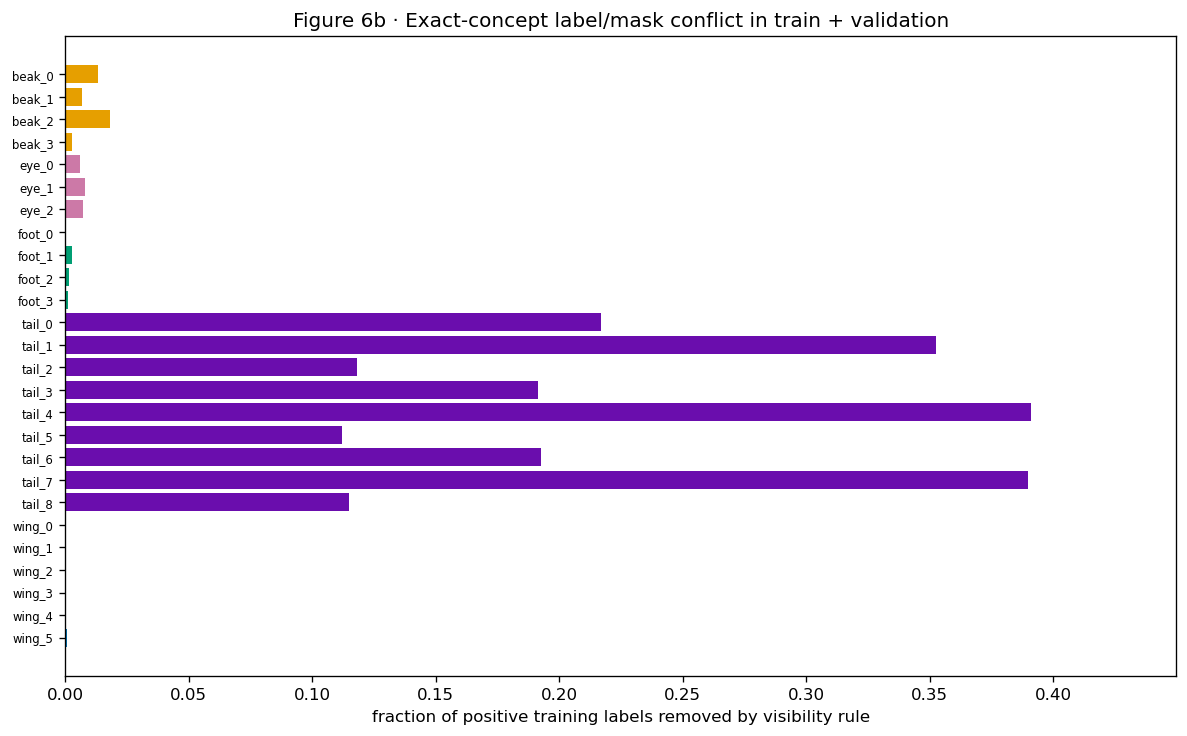

Figure 6b denominators by split:


,split,images,positive_labels,positive_to_zero_conflicts
0,train,45000,169626,7346
1,val,5000,18835,838


Figure 6b exact-concept and part totals:


,concept,part,n_positive,n_changed,conflict_rate
0,beak_0,beak,15819,210,0.013
1,beak_1,beak,7476,49,0.007
2,beak_2,beak,4555,83,0.018
3,beak_3,beak,9767,25,0.003
4,eye_0,eye,11384,67,0.006
5,eye_1,eye,11994,97,0.008
6,eye_2,eye,14348,104,0.007
7,foot_0,foot,9829,2,0.000
8,foot_1,foot,7584,21,0.003
9,foot_2,foot,10552,14,0.001


,n_positive,n_changed,conflict_rate
part,,,
tail,37707,7489,0.199
wing,37688,12,0.000
beak,37617,367,0.010
foot,37723,48,0.001
eye,37726,268,0.007


In [11]:
# ALT: FunnyBird training-image counts whose positive part-concept labels change under the matched visibility-aware relabeling rule.
import pickle
standard_input=CURATED/"koh_joint_inputs"/"funnybirds"/"standard"
visibility_input=CURATED/"koh_joint_inputs"/"funnybirds"/"rlv2"
pairs=[]
for split in ["train","val"]:
    std_path=standard_input/f"{split}.pkl"
    visibility_path=visibility_input/f"{split}.pkl"
    if not (std_path.exists() and visibility_path.exists()):
        raise RuntimeError(f"missing matched {split} label views: {std_path} or {visibility_path}")
    std=pickle.loads(std_path.read_bytes())
    visibility=pickle.loads(visibility_path.read_bytes())
    if len(std)!=len(visibility):
        raise RuntimeError(f"standard/visibility-aware {split} lengths differ")
    pairs.extend((split,a,b) for a,b in zip(std,visibility))
positive=np.zeros(len(CONCEPT_NAMES),dtype=int); changed=np.zeros(len(CONCEPT_NAMES),dtype=int)
split_rows=[]
for split in ["train","val"]:
    split_positive=np.zeros(len(CONCEPT_NAMES),dtype=int)
    split_changed=np.zeros(len(CONCEPT_NAMES),dtype=int)
    for _,a,b in [row for row in pairs if row[0]==split]:
        for key in a:
            if key=="attribute_label": continue
            av,bv=a[key],b[key]
            equal=np.array_equal(np.asarray(av),np.asarray(bv)) if isinstance(av,(list,tuple,np.ndarray)) else av==bv
            if not bool(equal): raise RuntimeError(f"non-label record field differs in {split}: {key}")
        ca=np.asarray(a["attribute_label"]); cb=np.asarray(b["attribute_label"])
        split_positive += (ca==1); split_changed += ((ca==1)&(cb==0))
    positive += split_positive; changed += split_changed
    split_rows.append({"split":split,"images":sum(row[0]==split for row in pairs),
                       "positive_labels":int(split_positive.sum()),
                       "positive_to_zero_conflicts":int(split_changed.sum())})
CONFLICT_EXACT=pd.DataFrame({"concept":CONCEPT_NAMES,"part":[CONCEPT_PART[n] for n in CONCEPT_NAMES],
    "n_positive":positive,"n_changed":changed})
CONFLICT_EXACT["conflict_rate"]=CONFLICT_EXACT.n_changed/CONFLICT_EXACT.n_positive.replace(0,np.nan)
PART_CONFLICT=(CONFLICT_EXACT.groupby("part").agg(n_positive=("n_positive","sum"),
    n_changed=("n_changed","sum")).reindex(ORDER))
PART_CONFLICT["conflict_rate"]=PART_CONFLICT.n_changed/PART_CONFLICT.n_positive
q=CONFLICT_EXACT.sort_values(["part","concept"]); y=np.arange(len(q))
fig,ax=plt.subplots(figsize=(10,max(6,.24*len(q))))
ax.barh(y,q.conflict_rate,color=q.part.map(COLORS)); ax.set_yticks(y,q.concept,fontsize=7)
ax.invert_yaxis()
conflict_axis_max=max(.05,min(1.0,float(q.conflict_rate.max())*1.15))
ax.set_xlim(0,conflict_axis_max)
ax.set_xlabel("fraction of positive training labels removed by visibility rule")
ax.set_title("Figure 6b · Exact-concept label/mask conflict in train + validation")
plt.tight_layout(); plt.show()
print("Figure 6b denominators by split:")
display(pd.DataFrame(split_rows))
print("Figure 6b exact-concept and part totals:")
display(q.round(3)); display(PART_CONFLICT.round(3))


    ### Plain-language reference for Figure 6b

    **Plain caption.** Original supervision frequently marks a tail concept present when its renderer pixels are invisible, while this conflict is rare for wing and foot.

    **Terms and how to read it.** The numerator is original positive labels changed to zero by the visibility rule; the denominator is all original positive labels for that concept or part. This is a data-conflict rate, not a model probability.

    **Literal values.** Across the 45,000 training and 5,000 validation images, the visibility rule removes 8,184 of 188,461 positive labels. By part, it removes 7,489/37,707 tail labels (0.199), 367/37,617 beak (0.010), 268/37,726 eye (0.007), 48/37,723 foot (0.001), and 12/37,688 wing (less than 0.001).

    **Interpretation.** The ordinary training labels often say a tail value is present when the tail pixels are not visible. This happens for about one tail label in five but is almost absent for wing and foot. Such supervision could teach the model to infer tail from the rest of the bird; notebook 02rl tests that causal proposal by changing the labels and retraining.

**Strongest alternative explanation.** These are training-signal counts, not measured causal effects on the trained standard model.

    **Discriminating test.** Compare otherwise matched standard and RLv2 checkpoints on the same fixed renders.

    **Verdict.** **KEEP**.

    **Proof ledger.** `ACCEPTED FOR a measured, part-specific label/visibility conflict. It is extremely large for tail, small but nonzero for beak/eye, and near zero for wing/foot. This can explain tail's excess severity but cannot by itself explain backwash in every part; causal credit remains deferred to notebook 02rl.`

    **Next question.** Are some exact visual variants much harder than others?


## 7 · Do exact source and donor values explain the failures?

**Question.** Do exact source and donor values explain the failures?

**Variables and prediction.** For every part, compare the inserted donor value with the concept value that has the largest post-swap raw score. A clean diagonal means exact visual values are distinguished; recurring bright columns indicate default answers.

**Method.** Display all parts and all values with row-normalized counts.

### Figure 7 · Do exact source and donor values explain the failures?

**How to read the figure.** Each heatmap row is the value actually inserted and each column is the value
with the largest post-swap raw logit. A bright diagonal means the model names
the inserted value; bright off-diagonal cells show systematic confusion.
Every FunnyBird part and every value is included. The lower row gives the
final-margin distribution for the same inserted values, with the number of
swaps printed above each box. Thus recognition and retained-source margin are
visible together rather than inferred from a diagonal rate alone. A diagonal
value of 0.80 means the inserted value is highest in 80% of that row's swaps.


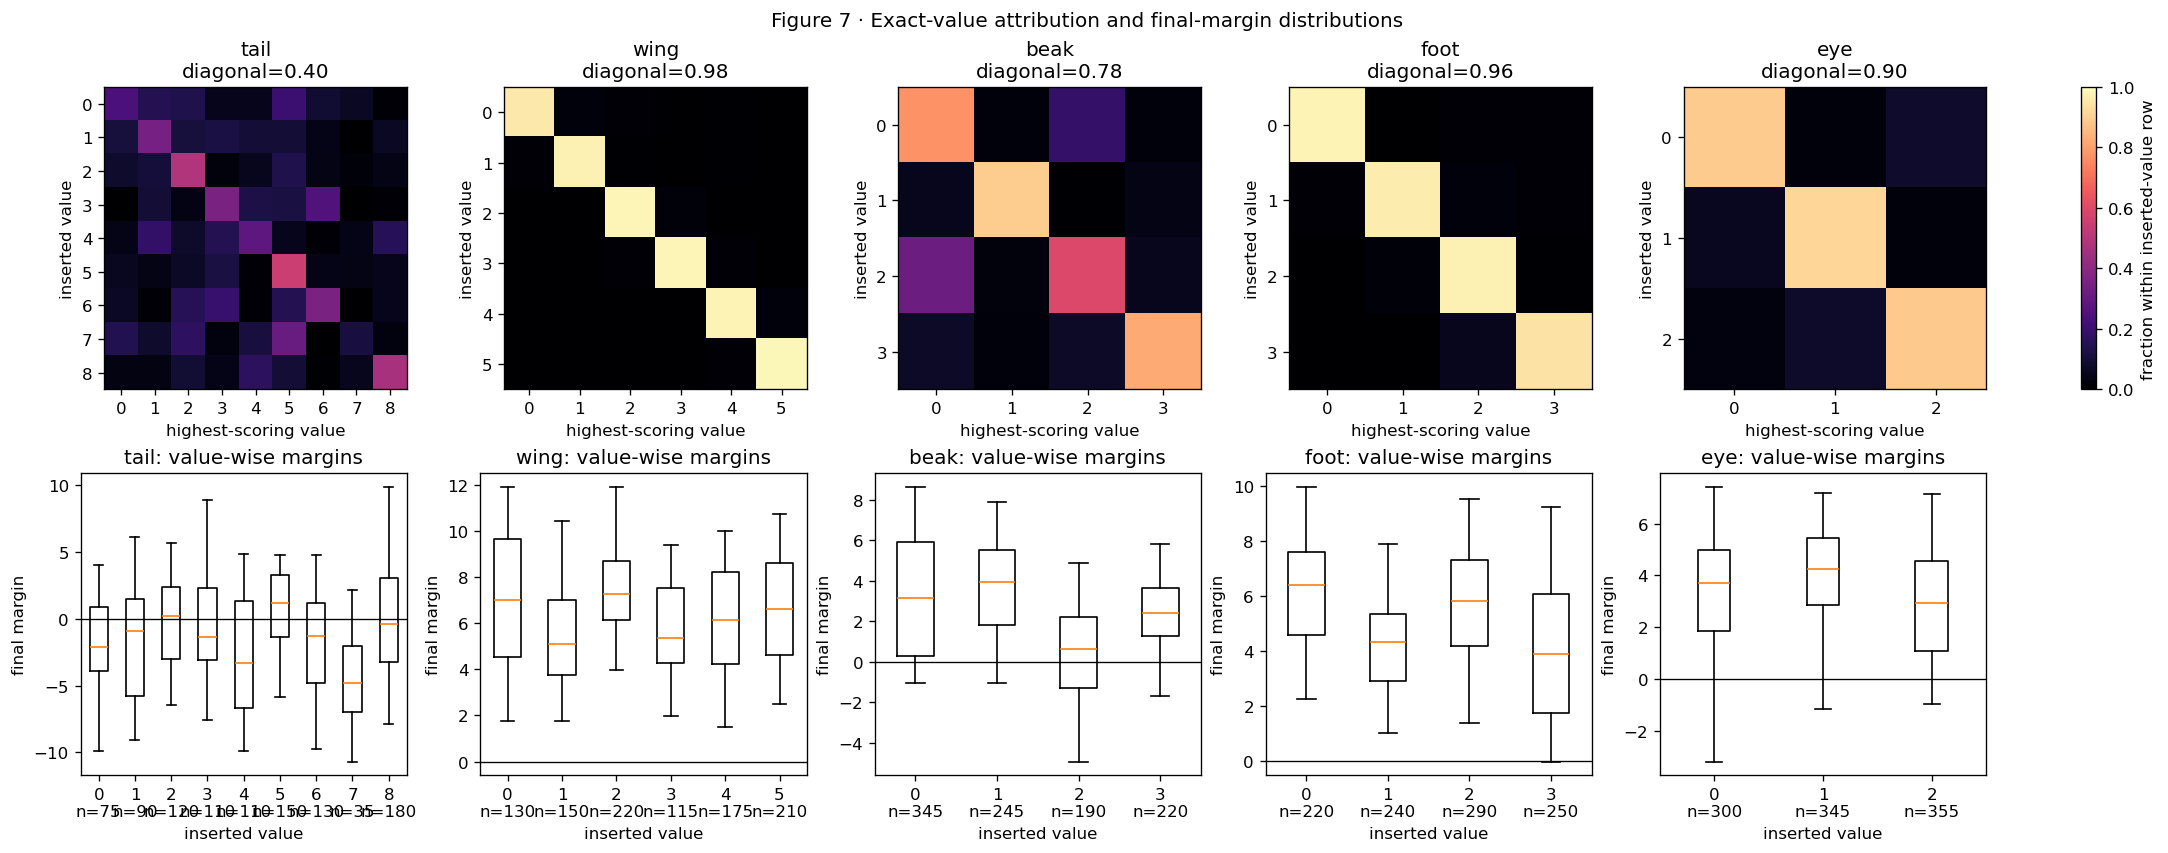

,diagonal_rate
tail,0.395
wing,0.977
beak,0.780
foot,0.965
eye,0.900


,part,donor_value,n,median_margin,q25_margin,q75_margin,event_rate
0,tail,0,75,-2.150,-3.892,0.873,0.640
1,tail,1,90,-0.932,-5.808,1.446,0.533
2,tail,2,120,0.163,-3.022,2.348,0.408
3,tail,3,110,-1.360,-3.104,2.295,0.573
4,tail,4,110,-3.283,-6.689,1.349,0.518
5,tail,5,150,1.166,-1.377,3.287,0.373
6,tail,6,130,-1.289,-4.784,1.151,0.515
7,tail,7,35,-4.796,-6.947,-2.045,0.800
8,tail,8,180,-0.378,-3.255,3.067,0.478
9,wing,0,130,6.996,4.536,9.665,0.031


In [12]:
# ALT: Five row-normalized confusion matrices comparing inserted and highest-scoring FunnyBird part values.
available=[p for p in ORDER if any(c.startswith(f"z_cf_{p}_") for c in S.columns)]
if set(available)!=set(ORDER): raise RuntimeError(f"missing all-part post-swap concept logits: have {available}")
fig,axes=plt.subplots(2,5,figsize=(18,7),constrained_layout=True)
diag={}
value_rows=[]
for col,p in enumerate(ORDER):
    ax=axes[0,col]; bax=axes[1,col]
    cols=sorted([c for c in S if c.startswith(f"z_cf_{p}_")],key=lambda x:int(x.rsplit("_",1)[1]))
    d=S[S.part==p].dropna(subset=cols); donor=d.var_donor.astype(int).to_numpy(); pred=d[cols].to_numpy().argmax(1)
    M=np.zeros((len(cols),len(cols)))
    for a,b in zip(donor,pred):
        if 0<=a<len(cols): M[a,b]+=1
    M=M/np.maximum(M.sum(1,keepdims=True),1); diag[p]=(donor==pred).mean()
    im=ax.imshow(M,vmin=0,vmax=1,cmap="magma"); ax.set_title(f"{p}\ndiagonal={diag[p]:.2f}")
    ax.set_xticks(np.arange(len(cols))); ax.set_yticks(np.arange(len(cols)))
    ax.set_xlabel("highest-scoring value"); ax.set_ylabel("inserted value")
    groups=[]; labels=[]
    for v,g in d.groupby("var_donor"):
        groups.append(g.margin.to_numpy()); labels.append(str(int(v)))
        value_rows.append({"part":p,"donor_value":int(v),"n":len(g),"median_margin":g.margin.median(),
            "q25_margin":g.margin.quantile(.25),"q75_margin":g.margin.quantile(.75),
            "event_rate":g.responded_but_source_wins.mean()})
    count_labels=[f"{lab}\nn={len(g)}" for lab,g in zip(labels,groups)]
    bax.boxplot(groups,tick_labels=count_labels,showfliers=False,whis=(5,95)); bax.axhline(0,color="black",lw=.8)
    bax.set_xlabel("inserted value"); bax.set_ylabel("final margin"); bax.set_title(f"{p}: value-wise margins")
colorbar=fig.colorbar(im,ax=list(axes[0]),fraction=.015)
colorbar.set_label("fraction within inserted-value row")
fig.suptitle("Figure 7 · Exact-value attribution and final-margin distributions")
plt.show(); display(pd.Series(diag,name="diagonal_rate").to_frame().round(3)); display(pd.DataFrame(value_rows).round(3))


    ### Plain-language reference for Figure 7

    **Plain caption.** Exact inserted-value recognition is weakest for tail and graded across the other parts, showing that value-level visual difficulty accompanies the swap failures.

    **Terms and how to read it.** A heatmap row is the inserted exact value and a column is the highest-scoring value. Row-normalized color is the fraction of that inserted-value population. The lower boxes show final margins and print swap counts.

    **Literal values.** Post-swap donor-value recognition is graded: diagonal rates are tail 0.395, wing 0.977, beak 0.780, foot 0.965, and eye 0.900. Tail value 7 has only 35 swaps, a median final margin of -4.796, and event rate 0.800; beak value 2 is the next conspicuous difficult value at rate 0.363.

    **Interpretation.** After a tail is inserted, the model names the inserted tail value as its top tail answer only 39.5% of the time. It is much better for wing, foot, and eye. Therefore tail is not merely hard to see; choosing among its nine exact alternatives is also difficult.

**Strongest alternative explanation.** Different parts have different numbers and frequencies of variants, so raw diagonal rates are not directly interchangeable.

    **Discriminating test.** Relate each donor value to species support and its part's alternative count.

    **Verdict.** **KEEP**.

    **Proof ledger.** `ACCEPTED FOR exact-value difficulty as an additional graded contributor across all five parts, not as a tail-only explanation.`

    **Next question.** Do rarity or a larger choice set organize those value-level failures?


## 7b · Are difficult values simply rare or drawn from a larger alternative set?

**Question.** Are difficult values simply rare or drawn from a larger alternative set?

**Variables and prediction.** For every exact donor value, compare its species support with all three mutually exclusive outcomes from Figure 4b; also report the total number of alternatives for its part. If rarity organizes the result, lower-support values should systematically win less or fail more. A mixed pattern rejects support as a sufficient explanation.

**Method.** Label every exact value, print its swap-row denominator, and verify that its three outcome fractions sum to one.

### Figure 7b · Are difficult values simply rare or drawn from a larger alternative set?

**How to read the figure.** Each labelled point is one exact donor value. The x-axis is its species
support: the number of the 50 FunnyBird species that naturally carry that
value in an unmodified bird. It is not an image count or swap count. The
three panels partition all swaps into donor wins, donorward movement that
remains source-negative, and no donorward movement while source-negative.
The three fractions sum to one within each value. A consistent relationship
with support would make rarity a plausible organizer. The number of
alternatives is reported but cannot be cleanly separated with only five
parts.


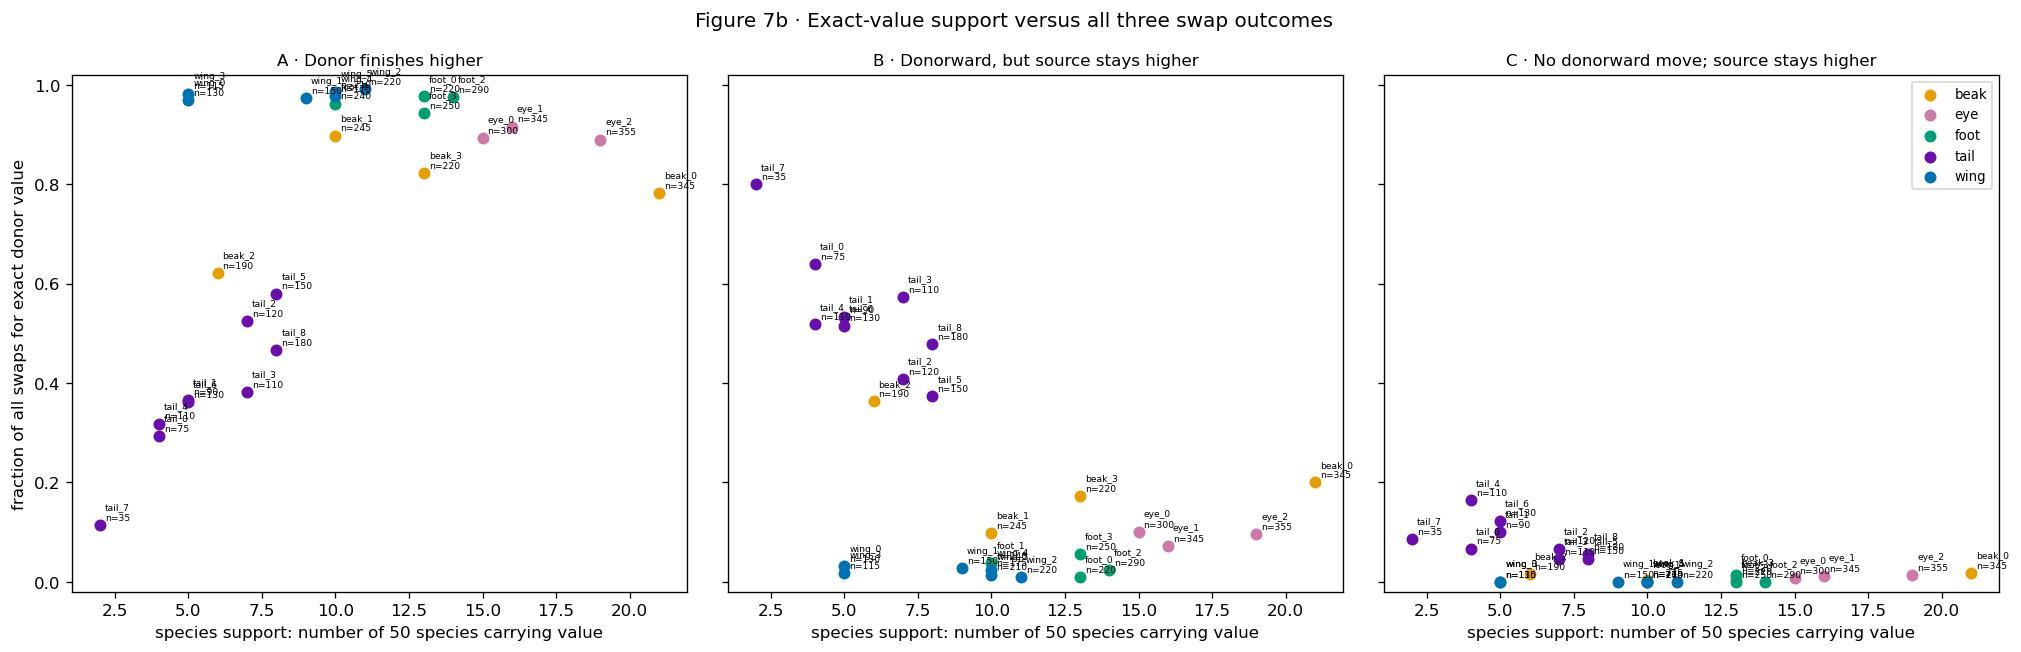

,part,var_donor,n_rows,species_support,donor_wins_rate,responded_but_source_wins_rate,no_donorward_move_rate,median_margin,alternatives_in_part
0,beak,0,345,21,0.783,0.200,0.017,3.144,4
1,beak,1,245,10,0.898,0.098,0.004,3.960,4
2,beak,2,190,6,0.621,0.363,0.016,0.614,4
3,beak,3,220,13,0.823,0.173,0.005,2.426,4
4,eye,0,300,15,0.893,0.100,0.007,3.715,3
5,eye,1,345,16,0.916,0.072,0.012,4.247,3
6,eye,2,355,19,0.890,0.096,0.014,2.946,3
7,foot,0,220,13,0.977,0.009,0.014,6.397,4
8,foot,1,240,10,0.962,0.038,0.000,4.330,4
9,foot,2,290,14,0.976,0.024,0.000,5.813,4


In [13]:
# ALT: Three labelled FunnyBird exact-value panels showing species support against donor wins, donorward-but-source-still-wins events, and no-donorward-movement failures.
VALUE_OUTCOMES=S.assign(
    donor_wins=S.m_cf>0,
    helped_but_source_wins=(S.m_cf<=0)&(S.response_delta>0),
    no_donorward_move_and_source_wins=(S.m_cf<=0)&(S.response_delta<=0),
)
VS=(VALUE_OUTCOMES.groupby(["part","var_donor"]).agg(
     n_rows=("margin","size"),species_support=("sid_donor","nunique"),
     donor_wins_rate=("donor_wins","mean"),
     responded_but_source_wins_rate=("helped_but_source_wins","mean"),
     no_donorward_move_rate=("no_donorward_move_and_source_wins","mean"),
     median_margin=("margin","median")).reset_index())
VS["alternatives_in_part"]=VS.part.map({p:hi-lo for p,(lo,hi) in SPANS.items()})
sums=VS[["donor_wins_rate","responded_but_source_wins_rate","no_donorward_move_rate"]].sum(axis=1)
if not np.allclose(sums,1): raise RuntimeError("value-level outcome fractions do not sum to one")
panels=[("donor_wins_rate","A · Donor finishes higher"),
        ("responded_but_source_wins_rate","B · Donorward, but source stays higher"),
        ("no_donorward_move_rate","C · No donorward move; source stays higher")]
fig,axes=plt.subplots(1,3,figsize=(17,5.5),sharex=True,sharey=True)
for ax,(column,title) in zip(axes,panels):
    for p,d in VS.groupby("part"):
        ax.scatter(d.species_support,d[column],s=38,color=COLORS[p],label=p)
        for r in d.itertuples():
            ax.annotate(f"{p}_{int(r.var_donor)}\nn={int(r.n_rows)}",
                        (r.species_support,getattr(r,column)),fontsize=5.5,
                        xytext=(3,3),textcoords="offset points")
    ax.set_xlabel("species support: number of 50 species carrying value")
    ax.set_title(title,fontsize=10); ax.set_ylim(-.02,1.02)
axes[0].set_ylabel("fraction of all swaps for exact donor value")
axes[-1].legend(fontsize=8)
fig.suptitle("Figure 7b · Exact-value support versus all three swap outcomes")
plt.tight_layout(); plt.show(); display(VS.round(3))


    ### Plain-language reference for Figure 7b

    **Plain caption.** Rarity sometimes accompanies difficult exact values, but support does not cleanly determine whether the donor wins, helps but loses, or fails to move the score.

    **Terms and how to read it.** Species support is the number of the 50 species naturally carrying an exact value. The three y-axes are mutually exclusive fractions with all swaps for that donor value as denominator; together they sum to one.

    **Literal values.** All three outcome panels use every swap for each donor value and close to one. Lower-support values are sometimes difficult—tail value 7 has support from two species and controlled-event rate 0.800, and beak value 2 has support from six species and rate 0.363—but donor wins, insufficient donorward corrections, and no-movement failures are not monotone in support within every part. Tail remains difficult and wing/foot strong across overlapping support values.

    **Interpretation.** Some rare values are especially difficult, but rarity is not a complete rule. Values with similar support can have different event rates, and the number of alternatives changes only between parts, where many other properties also change.

**Strongest alternative explanation.** The number of alternatives is constant within a part and therefore remains confounded with all other part-level differences.

    **Discriminating test.** Use more independent part families or a design that changes choice-set size while holding pixels and species fixed.

    **Verdict.** **KEEP**.

    **Proof ledger.** `VALID TEST, NO CLEAR SUPPORT that frequency or alternative count alone explains the part ordering; revised all-outcome display is INCOMPLETE pending rerender.`

    **Next question.** Does unchanged source species organize what remains after exact values?


## 8 · Does source species organize the remaining error after exact values?

**Question.** If two birds receive the same exact replacement, do their
source species still accompany systematically different final margins?

**Why exact-pair centering is needed.** A species could appear resistant
merely because it happens to receive difficult replacements. We first
compare each row only with swaps having the same part, old exact value,
and inserted exact value. This removes that composition difference before
species are summarized.

**Complete procedure.**

```text
for each swap row:
    exact_pair = (part, source_value, donor_value)

for each exact_pair:
    pair_mean = average final margin across all its rows

for each row:
    row_residual = row final margin - its pair_mean

for each (part, source_species):
    species_residual = average row_residual

display species only when it has at least five rows
```

**Numerical example.** Suppose red-tail to blue-tail margins are `-5`
and `-3` for Species A and `+1` and `+3` for Species B. Their exact-pair
mean is `-1`. The residuals are therefore `-4,-2,+2,+4`: they average to
zero over the pair, but Species A averages `-3` and Species B averages
`+3`. Species A is more source-retaining than the exact-pair average.

**Prediction and limit.** Persistent species residuals support an
unchanged-body/species association after exact values. They do not prove
that species causes it because species remains bundled with body shape,
pose tendencies, and other renderer properties.

### Figure 8 · Source-species residual after exact source/donor values

**How to read the figure.** Rows preserve source-species identity and
columns preserve part. Blue cells are more source-retaining than the
corresponding exact-pair means; red cells are more donor-receptive;
white is zero. Blank cells lack five rows. The same species row is used
across all parts, unlike independently sorting each panel.


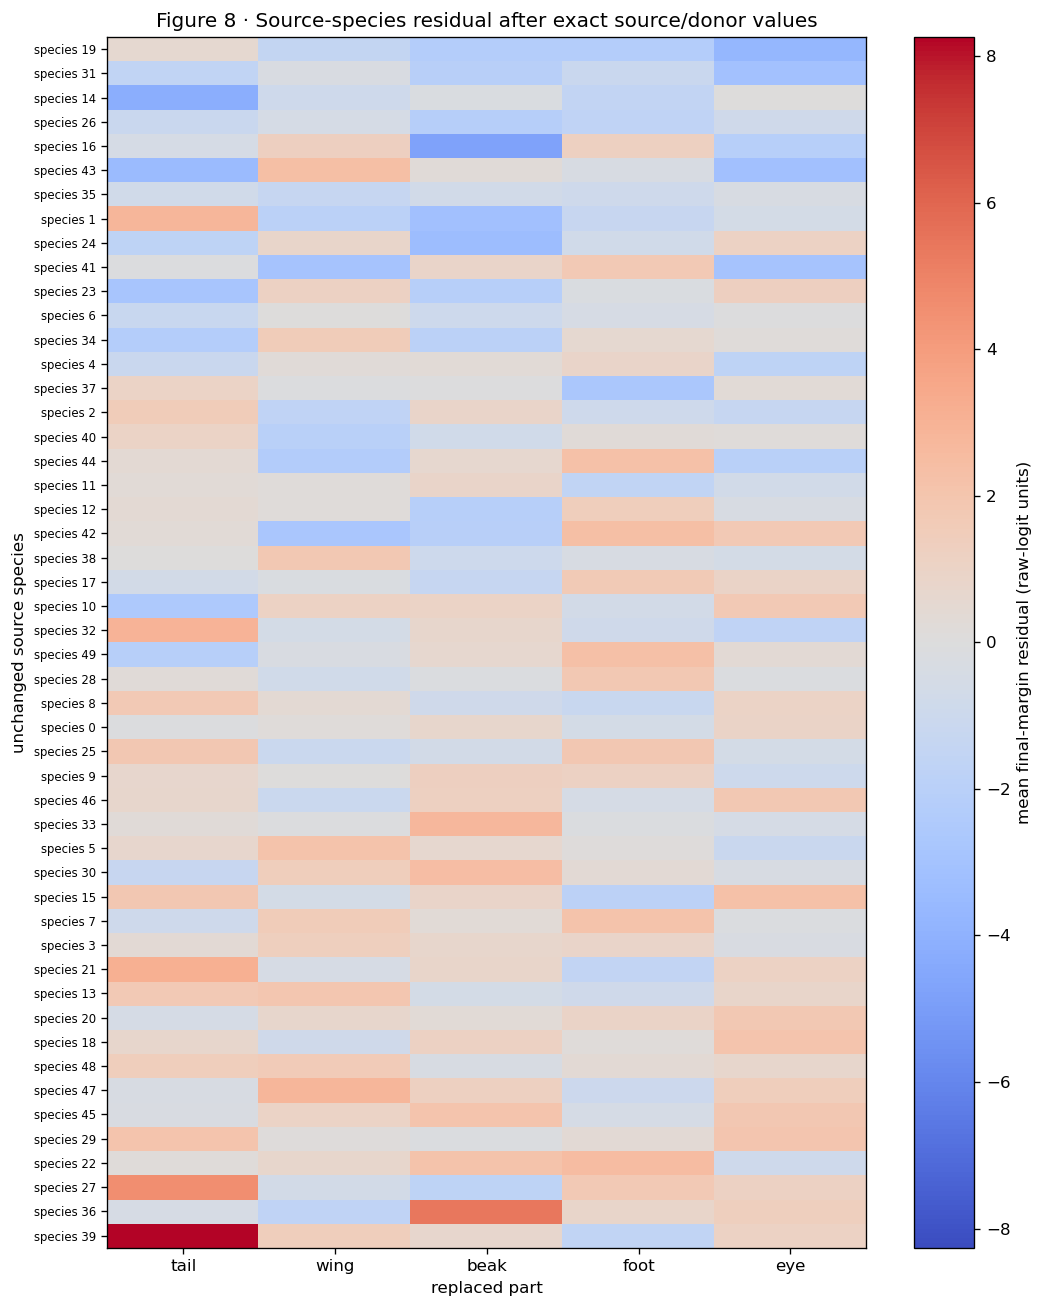

,min,median,max,std,count
part,,,,,
beak,-4.736,0.252,5.401,1.733,50
eye,-3.685,0.019,2.229,1.466,50
foot,-2.702,-0.183,2.512,1.342,50
tail,-4.173,0.245,8.259,2.043,50
wing,-2.927,0.032,2.816,1.341,50


maximum absolute within-exact-pair residual mean: 1.0658141036401502e-15


In [14]:
# ALT: Heatmap preserving source-species identity across parts after subtracting each exact source/donor value-pair mean.
R=S.copy(); R["value_pair_mean"]=R.groupby(["part","var_src","var_donor"]).margin.transform("mean")
R["margin_after_value_pair"]=R.margin-R.value_pair_mean
pair_zero=R.groupby(["part","var_src","var_donor"]).margin_after_value_pair.mean().abs().max()
if pair_zero>1e-10: raise RuntimeError(f"exact-pair residual means do not close: {pair_zero}")
SP=(R.groupby(["part","sid_src"]).agg(n=("margin","size"),residual=("margin_after_value_pair","mean"))
      .reset_index().query("n>=5"))
matrix=SP.pivot(index="sid_src",columns="part",values="residual").reindex(columns=ORDER)
matrix=matrix.loc[matrix.mean(axis=1).sort_values().index]
lim=float(np.nanmax(np.abs(matrix.to_numpy())))
fig,ax=plt.subplots(figsize=(9,max(7,.22*len(matrix))))
im=ax.imshow(matrix.to_numpy(),aspect="auto",cmap="coolwarm",vmin=-lim,vmax=lim)
ax.set_xticks(np.arange(len(ORDER)),ORDER)
ax.set_yticks(np.arange(len(matrix)),[f"species {int(x)}" for x in matrix.index],fontsize=7)
ax.set_xlabel("replaced part"); ax.set_ylabel("unchanged source species")
ax.set_title("Figure 8 · Source-species residual after exact source/donor values")
cb=fig.colorbar(im,ax=ax); cb.set_label("mean final-margin residual (raw-logit units)")
plt.tight_layout(); plt.show()
display(SP.groupby("part").residual.agg(["min","median","max","std","count"]).round(3))
print("maximum absolute within-exact-pair residual mean:",pair_zero)


    ### Plain-language reference for Figure 8

    **Plain caption.** After matching the exact source and donor values, source species still organize final margins descriptively, but the plot does not isolate a causal species effect.

    **Terms and how to read it.** An exact pair is `(part, source value, donor value)`. A row residual is its final margin minus that pair's pooled mean. Species residual is the average of those row residuals for one source species; within-pair residuals average to zero, but within-species residuals need not.

    **Literal values.** After centering each part/source-value/donor-value combination, source-species mean residuals remain nonzero in every part. Their standard deviations are tail 2.043, beak 1.733, eye 1.466, foot 1.342, and wing 1.341 raw-logit units; tail ranges from -4.173 to 8.259.

    **Interpretation.** Even for the same source and donor values, some source species shift the margin upward and others downward. This says the unchanged bird background is associated with the answer, but this particular plot reuses the same rows to estimate and summarize the shift, so it is descriptive.

**Strongest alternative explanation.** The descriptive species means can also absorb pose or repeated-row composition, and they are not a causal body manipulation.

    **Discriminating test.** Check whether species is recoverable from held-out concept vectors and whether species improves held-out margin prediction.

    **Verdict.** **KEEP**.

    **Proof ledger.** `ACCEPTED NUMERICALLY FOR an observational source-species association beyond exact values in every part; the common-identity heatmap is INCOMPLETE pending rerender and visual review. The figure does not establish causal size.`

    **Next question.** Is species information actually present in the learned concept representation?


## 8b · How much species identity is recoverable from the learned concept vector?

**Question.** How much species identity is recoverable from the learned concept vector?

**Variables and prediction.** Train three matched diagnostic species classifiers after the CBM is finished. Grey receives known binary concept labels c; color receives raw scores z; outline receives each z after subtracting the training-fold mean for its own 0/1 label bucket. Raw or residual accuracy above the known-label control means score magnitudes reveal species beyond the nominal concept pattern. It does not say which pixels produced them, whether the saved class head uses them, or whether they caused a swap failure.

**Method.** Use one fixed stratified 70/30 split of the held-out prediction population.

### Figure 8b · How much species identity is recoverable from the learned concept vector?

**How to read the figure.** The y-axis is held-out species-classification accuracy. For every block, grey
uses processed 0/1 concept labels, color uses learned raw logits, and the
outlined bar uses raw logits after the training-fold mean for the same 0/1
label has been removed. The grey bar is the structural control: with balanced
FunnyBird species and `K` mutually exclusive values for one part, it is
approximately `K/50` (tail has 9 values, so 9/50=0.18), not 1/50. The residual
bar asks whether score magnitudes still identify species after the nominal
label bucket is removed. This diagnoses available information only; it does
not prove that the saved CBM uses it or that it caused backwash.


### Before Figure 8b: what exactly are the grey and colored bars?

Each image has a processed binary label vector `c`. For example, a row can
contain `beak_0=1`, `beak_1=0`, ..., `wing_3=1`. These are the dataset's
known yes/no concept answers after preprocessing; they are not model scores.

We train separate diagnostic classifiers whose target is the species `y`:

- **grey bar:** input is the corresponding block of known 0/1 labels `c`;
- **colored bar:** input is the corresponding block of learned raw scores `z`;
- **outlined bar:** input is `z` after subtracting the training-fold mean
  for the same exact concept and 0/1 label. This asks whether magnitudes
  still identify species *within* the official label buckets;
- **bar height:** held-out species accuracy of that diagnostic classifier.

Thus “species information is present” means only that a classifier can guess
species from the supplied numbers better than chance. It does **not** mean the
saved CBM classified the image with that accuracy, and it does **not** measure
whether a concept used its named pixels.

Example: one tail value divides 50 species into a smaller bucket. Even a
perfect label-only rule usually cannot identify which species inside that
bucket produced the image. If raw score magnitudes separate those species,
they contain extra within-bucket information. The grey label bar measures
the achievable structural baseline empirically; blind `1/50` guessing is
therefore not drawn as the comparison line.

A single part block is supplied as several numbers to a multinomial
logistic regression. For example, the nine tail scores become nine input
columns, and the diagnostic fits 50 weighted sums—one per species. We are
not zeroing other weights in the saved CBM because this is a new diagnostic
classifier. Figure 8c separately tests the existing saved linear head.

> **IMPORTANT: Species leakage makes backwash possible, but leakage alone does
> not cause it. Wing is the clearest counterexample: wing `z` reveals species,
> yet the controlled swaps show strong grounding.**

What predicts grounding is measured separately: `response_delta`, final margin
`m_cf`, target-part visibility, label/mask conflict, and exact donor-value
recognition. Figure 8b is an availability/control diagnostic, not that outcome.


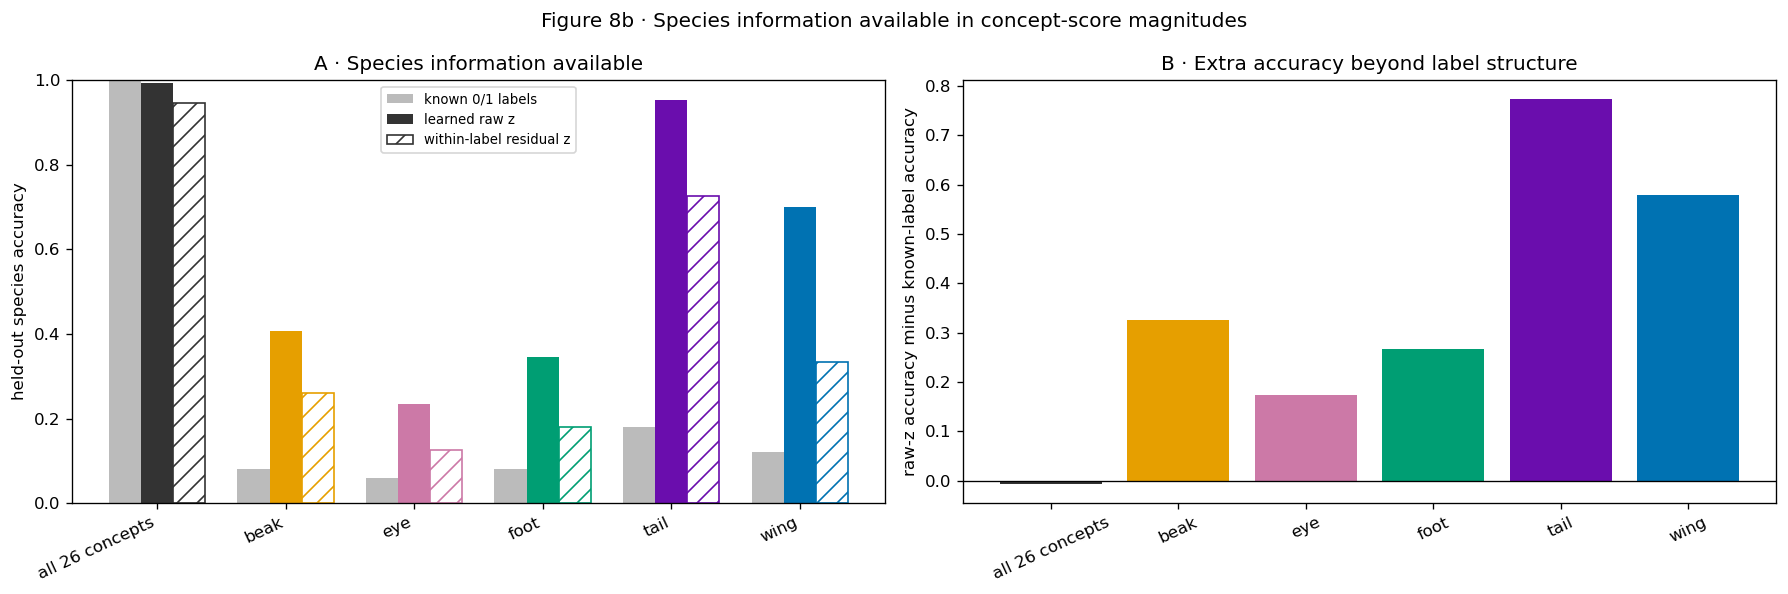

,block,raw_z_accuracy,within_label_residual_accuracy,processed_label_accuracy,label_patterns,dimensions
0,all 26 concepts,0.993,0.947,1.00,50,26
1,beak,0.407,0.260,0.08,4,4
2,eye,0.233,0.127,0.06,3,3
3,foot,0.347,0.180,0.08,4,4
4,tail,0.953,0.727,0.18,9,9
5,wing,0.700,0.333,0.12,6,6


uninformed blind-guess accuracy (not the part-block baseline): 0.02


In [15]:
# ALT: Held-out FunnyBird species decoding from known labels, raw concept logits, and within-label residual logits, plus the raw-minus-label structural contrast.
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
idx=np.arange(len(y_saved)); tr,te=train_test_split(idx,test_size=.30,random_state=20260803,stratify=y_saved)
blocks={"all 26 concepts":np.arange(z_saved.shape[1])}
blocks.update({p:np.arange(lo,hi) for p,(lo,hi) in SPANS.items()})
label_means=np.zeros((z_saved.shape[1],2),dtype=float)
for j in range(z_saved.shape[1]):
    for label in [0,1]:
        rows=tr[c_saved[tr,j].astype(int)==label]
        if not len(rows): raise RuntimeError(f"no training-fold rows for concept {j}, label {label}")
        label_means[j,label]=z_saved[rows,j].mean()
residual_z=z_saved.copy()
for j in range(z_saved.shape[1]):
    residual_z[:,j]-=label_means[j,c_saved[:,j].astype(int)]
probe=[]
for name,cols in blocks.items():
    raw_model=make_pipeline(StandardScaler(),LogisticRegression(max_iter=4000,C=1.0,random_state=20260803))
    label_model=make_pipeline(StandardScaler(),LogisticRegression(max_iter=4000,C=1.0,random_state=20260803))
    residual_model=make_pipeline(StandardScaler(),LogisticRegression(max_iter=4000,C=1.0,random_state=20260803))
    raw_model.fit(z_saved[tr][:,cols],y_saved[tr]); label_model.fit(c_saved[tr][:,cols],y_saved[tr])
    residual_model.fit(residual_z[tr][:,cols],y_saved[tr])
    probe.append({"block":name,
                  "raw_z_accuracy":accuracy_score(y_saved[te],raw_model.predict(z_saved[te][:,cols])),
                  "within_label_residual_accuracy":accuracy_score(y_saved[te],residual_model.predict(residual_z[te][:,cols])),
                  "processed_label_accuracy":accuracy_score(y_saved[te],label_model.predict(c_saved[te][:,cols])),
                  "label_patterns":len(np.unique(c_saved[tr][:,cols],axis=0)),"dimensions":len(cols)})
PROBE=pd.DataFrame(probe)
x=np.arange(len(PROBE)); w=.25; block_colors=["#333333"]+[COLORS.get(name,"#999999") for name in PROBE.block.iloc[1:]]
fig,axes=plt.subplots(1,2,figsize=(15,5))
ax=axes[0]
ax.bar(x-w,PROBE.processed_label_accuracy,w,label="known 0/1 labels",color="#BBBBBB")
ax.bar(x,PROBE.raw_z_accuracy,w,label="learned raw z",color=block_colors)
ax.bar(x+w,PROBE.within_label_residual_accuracy,w,label="within-label residual z",facecolor="white",edgecolor=block_colors,hatch="//")
ax.set_xticks(x); ax.set_xticklabels(PROBE.block,rotation=25,ha="right")
ax.set_ylim(0,1); ax.set_ylabel("held-out species accuracy"); ax.set_title("A · Species information available")
ax.legend(fontsize=8)
extra=PROBE.set_index("block").raw_z_accuracy-PROBE.set_index("block").processed_label_accuracy
axes[1].bar(extra.index,extra.values,color=block_colors)
axes[1].axhline(0,color="black",lw=.8)
axes[1].set_ylabel("raw-z accuracy minus known-label accuracy")
axes[1].set_title("B · Extra accuracy beyond label structure")
axes[1].tick_params(axis="x",rotation=25)
fig.suptitle("Figure 8b · Species information available in concept-score magnitudes")
plt.tight_layout(); plt.show(); display(PROBE.round(3))
print("uninformed blind-guess accuracy (not the part-block baseline):",1/len(np.unique(y_saved)))


    ### Plain-language reference for Figure 8b

    **Plain caption.** Raw concept-score magnitudes contain species information beyond the known binary concept pattern; this is leakage availability, not yet use or grounding failure.

    **Terms and how to read it.** Grey is a diagnostic classifier using known binary labels; color uses learned raw `z`; outline uses within-label residual `z`. Bar height is held-out species accuracy. The known-label bar, not blind 1/50 guessing, is the meaningful structural baseline for each part block.

    **Literal values.** On the same held-out split, the previously reviewed contrast has all 26 raw logits decode species at 0.993 accuracy versus 1.000 from all labels. Individual raw-z blocks greatly exceed their label controls: beak 0.407 versus 0.080, eye 0.233 versus 0.060, foot 0.347 versus 0.080, tail 0.953 versus 0.180, and wing 0.700 versus 0.120. The newly added within-label residual bars are not yet rendered.

    **Interpretation.** The model's concept scores reveal far more about species than the official yes/no concept labels do. For example, tail scores identify species 95.3% of the time although the nine tail labels alone reach only 18.0%. Context information is therefore present inside the scores; presence alone does not prove it caused a replacement failure.

**Strongest alternative explanation.** Species decodability is not grounding: a score block can identify species while still responding correctly to its named pixels, as the controlled wing swaps show.

    **Discriminating test.** Judge grounding from response_delta and the final donor-minus-source margin, then relate those outcomes to visibility, conflict, and exact-value recognition.

    **Verdict.** **KEEP**.

    **Proof ledger.** `ACCEPTED FOR the paired label-versus-raw-z availability contrast; the within-label residual extension is INCOMPLETE pending rerender. Neither is a grounding test or evidence that species information alone causes backwash.`

    **Next question.** How much of the swap margin generalizes from the proposed explanatory blocks?


## 8c · Does the saved CBM class head actually use within-label score magnitudes?

**Question.** Figure 8b fits new diagnostic classifiers and therefore
proves only that species information is available. Does the already-trained
CBM's own linear species head rely on the same information?

**Method without retraining.** The saved head computes `Wz+b`. On the
held-out split, calculate the training-fold mean raw score for every exact
concept separately when its label is 0 and 1. Replace a test image's score
by the mean for its own known label, then pass that altered vector through
the unchanged saved `W` and `b`. This removes within-label magnitude while
preserving the binary concept pattern.

Example: if positive blue-tail scores average `+5` but one image has
`+8`, the replacement changes only that coordinate from `+8` to `+5`.
No class-head weight is refitted. If the species decision changes, the
existing CBM—not merely a new probe—was using that extra magnitude.

### Figure 8c · Existing-head reliance on within-label magnitudes

**How to read the figure.** Panel A compares saved-head accuracy using the
untouched raw vector with accuracy after all 26 coordinates are replaced
by label-conditioned means. Panel B replaces one part block at a time;
positive bars mean removing within-label magnitudes from that block lowers
accuracy. Zero means the saved head did not need that block's extra
magnitudes for these held-out decisions.


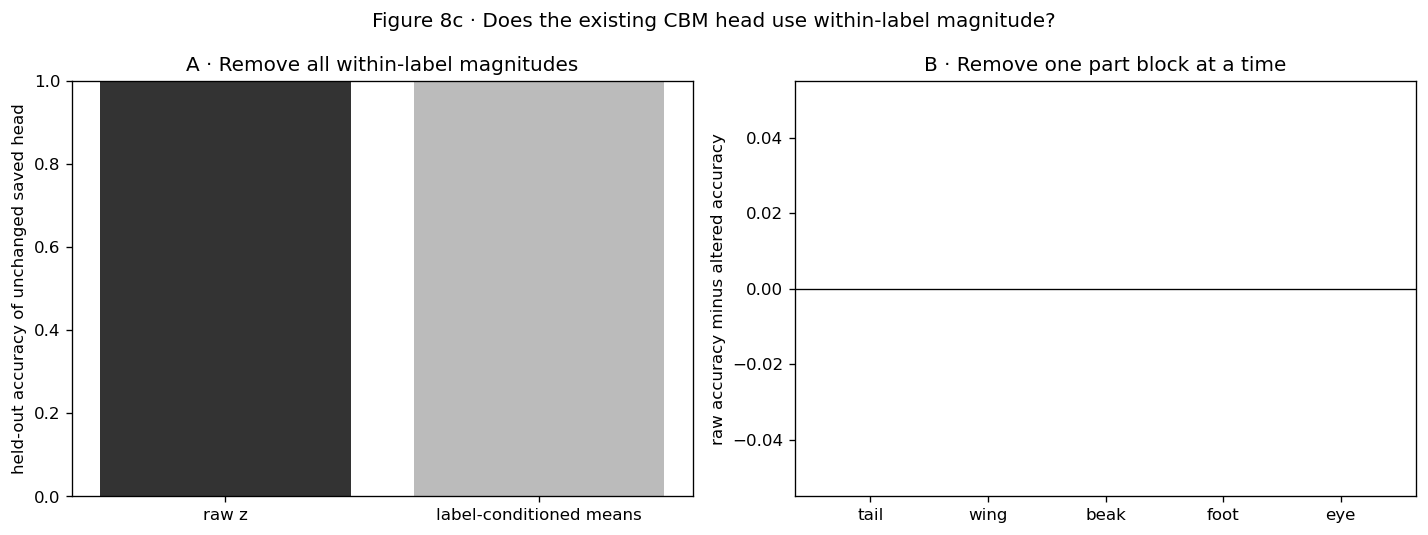

,raw_saved_head_accuracy,all_within_label_magnitude_removed_accuracy,accuracy_change
0,1.0,1.0,0.0


,part,accuracy_after_removing_within_label_magnitude,accuracy_drop,dimensions
0,tail,1.0,0.0,9
1,wing,1.0,0.0,6
2,beak,1.0,0.0,4
3,foot,1.0,0.0,4
4,eye,1.0,0.0,3


In [16]:
# ALT: Accuracy of the unchanged saved Koh linear species head before and after within-label raw-score magnitudes are removed globally or one part block at a time.
import torch
sys.path.insert(0,str(REPO/"compat"))
sys.path.insert(0,str(REPO/"external"/"ConceptBottleneck"))
try:
    saved_model=torch.load(MODEL,map_location="cpu",weights_only=False)
except TypeError:
    saved_model=torch.load(MODEL,map_location="cpu")
head=saved_model.sec_model.linear
W=head.weight.detach().cpu().numpy(); b=head.bias.detach().cpu().numpy()
if W.shape!=(50,26): raise RuntimeError(f"unexpected saved class-head shape {W.shape}")
raw_class_logits=z_saved@W.T+b
if not np.array_equal(raw_class_logits.argmax(1),y_pred_saved):
    raise RuntimeError("reconstructed saved linear-head predictions disagree with export")
expected_z=np.empty_like(z_saved)
for j in range(z_saved.shape[1]): expected_z[:,j]=label_means[j,c_saved[:,j].astype(int)]
raw_acc=float((raw_class_logits[te].argmax(1)==y_saved[te]).mean())
mean_acc=float(((expected_z@W.T+b)[te].argmax(1)==y_saved[te]).mean())
ablations=[]
for part,(lo,hi) in SPANS.items():
    altered=z_saved.copy(); altered[:,lo:hi]=expected_z[:,lo:hi]
    acc=float(((altered@W.T+b)[te].argmax(1)==y_saved[te]).mean())
    ablations.append({"part":part,"accuracy_after_removing_within_label_magnitude":acc,
                      "accuracy_drop":raw_acc-acc,"dimensions":hi-lo})
HEAD_USE=pd.DataFrame(ablations).set_index("part").reindex(ORDER).reset_index()
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
axes[0].bar(["raw z","label-conditioned means"],[raw_acc,mean_acc],color=["#333333","#BBBBBB"])
axes[0].set_ylim(0,1); axes[0].set_ylabel("held-out accuracy of unchanged saved head")
axes[0].set_title("A · Remove all within-label magnitudes")
axes[1].bar(HEAD_USE.part,HEAD_USE.accuracy_drop,color=[COLORS[p] for p in HEAD_USE.part])
axes[1].axhline(0,color="black",lw=.8); axes[1].set_ylabel("raw accuracy minus altered accuracy")
axes[1].set_title("B · Remove one part block at a time")
fig.suptitle("Figure 8c · Does the existing CBM head use within-label magnitude?")
plt.tight_layout(); plt.show()
display(pd.DataFrame([{"raw_saved_head_accuracy":raw_acc,
                       "all_within_label_magnitude_removed_accuracy":mean_acc,
                       "accuracy_change":raw_acc-mean_acc}]).round(3))
display(HEAD_USE.round(3))


### Review slot for Figure 8c

**Plain caption.** This figure distinguishes species information that a
new probe can recover from species information that the saved CBM's own
linear class head actually uses.

**Terms.** `Wz+b` is the unchanged saved 26-to-50 linear species head.
Label-conditioned mean replacement preserves whether each concept is 0
or 1 while removing the image-specific magnitude inside that label bucket.
Accuracy drop is original saved-head accuracy minus altered-input accuracy.

**Literal values and interpretation.** **INCOMPLETE until the revised
notebook executes from the accepted checkpoint and this complete figure
and both tables are inspected.** A positive drop will establish existing-
head use; no drop will keep Figure 8b as leakage availability only.

**Alternative.** An accuracy change can be caused by moving inputs away
from their training distribution, so the part-wise logit contribution and
controlled-swap link remain necessary.

**Verdict.** **MISSING EVIDENCE pending render**, not a negative result.

**Next question.** Does retained source-species evidence on the controlled
replacement accompany a more source-negative concept margin?


## 8d · Do off-target scores carry source-species evidence that is linked to swap failure?

**Final goal.** Determine whether distributed species information is a
mechanism relevant to the accepted controlled outcome, rather than an
interesting but irrelevant decoding fact.

**Hypothesis.** After replacing one part, the other exact-value outputs
in that same part block may retain a soft fingerprint of the unchanged
source species. If the saved class head reads that fingerprint, stronger
retained source-over-donor evidence should accompany a more negative
donor-minus-source concept margin.

**What “off-target” means.** In a red-to-blue tail swap, red and blue are
the target pair. The other seven tail outputs are off-target coordinates.
They are not irrelevant to the linear species head: every one has a saved
weight for every species. We subtract the expected score for each
counterfactual 0/1 label, then apply the existing source-species weight
minus donor-species weight to only those off-target residual scores.

Example: suppose the seven off-target residuals contribute `+2.0` to the
source class logit and `-0.5` to the donor class logit. Their retained
source-over-donor evidence is `+2.5` class-logit units. No probe or model
is trained.

**Controls and stopping rule.** Center both this evidence and the final
concept margin within the same exact `(part, source value, donor value)`
pair. If their within-pair association is absent, stop: species leakage
remains available but this test does not support it as an explanation.
If it is present, it is still an association because body, pose, and
visibility were not independently manipulated.

### Figure 8d · Existing-head off-target source fingerprint versus controlled outcome

**How to read the figure.** Panel A shows the within-exact-pair rank
correlation for every part; negative is the predicted direction because
more source-class evidence should accompany a more negative final concept
margin. Rank correlation compares order rather than raw scale: `-1` means
higher source evidence always accompanies lower margin, `0` means no
ordered relationship, and `+1` means they rise together. Panel B orders
rows into five equal-count evidence groups within each part and shows the
controlled-backwash fraction. Increasing lines support the hypothesis.
Every group prints its denominator in the table.


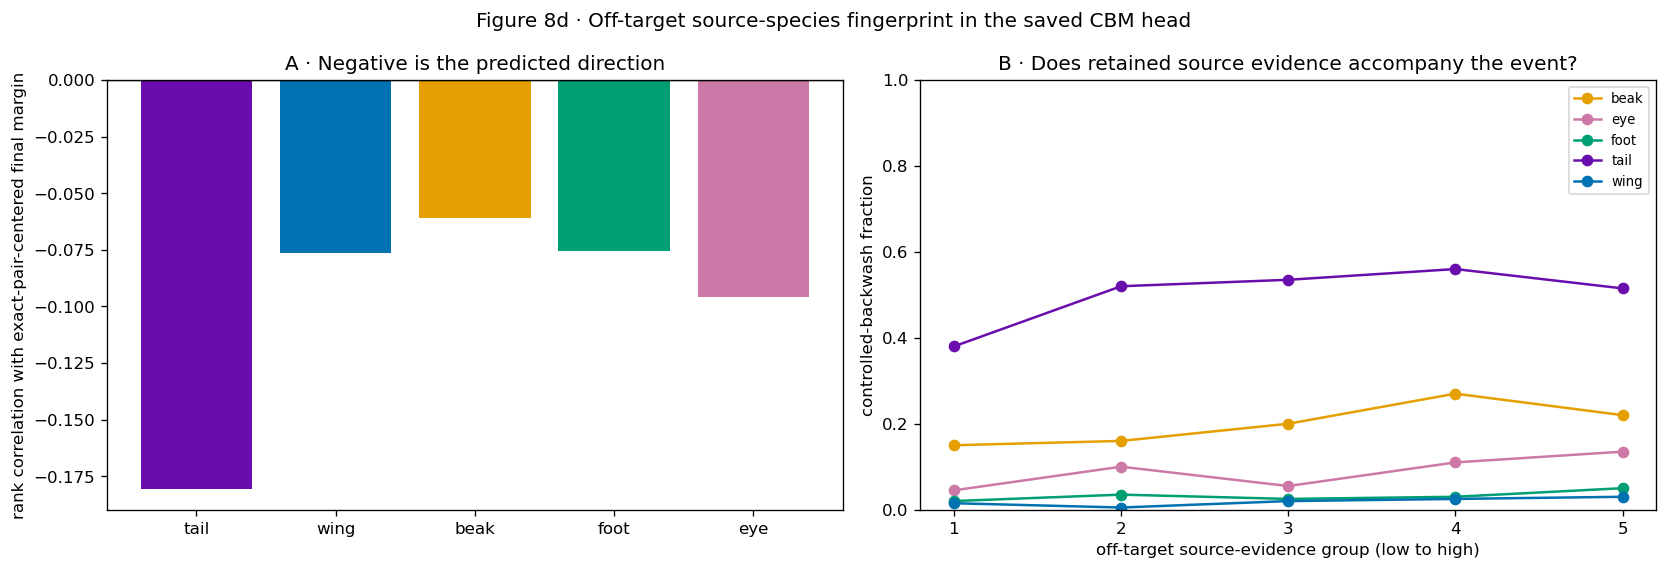

,part,rank_correlation,n
0,tail,-0.181,1000
1,wing,-0.076,1000
2,beak,-0.061,1000
3,foot,-0.076,1000
4,eye,-0.096,1000


,part,evidence_group,n,mean_evidence,controlled_backwash_rate,median_margin_after_pair
0,beak,1,200,-0.254,0.150,0.458
1,beak,2,200,-0.058,0.160,0.221
2,beak,3,200,0.006,0.200,-0.091
3,beak,4,200,0.066,0.270,-0.033
4,beak,5,200,0.241,0.220,0.185
5,eye,1,200,-0.118,0.045,0.548
6,eye,2,200,-0.017,0.100,0.465
7,eye,3,200,0.008,0.055,0.860
8,eye,4,200,0.030,0.110,-0.358
9,eye,5,200,0.097,0.135,0.058


In [17]:
# ALT: Within-exact-pair association between off-target source-over-donor evidence from the saved class head and the controlled FunnyBird outcome.
D=R.copy()
off_evidence=[]; pair_evidence=[]
for row in D.itertuples():
    part=row.part; lo,hi=SPANS[part]
    block_columns=[f"z_cf_{part}_{k}" for k in range(hi-lo)]
    values=np.asarray([getattr(row,column) for column in block_columns],dtype=float)
    if not np.isfinite(values).all(): raise RuntimeError(f"non-finite {part} counterfactual block")
    source_local=int(row.var_src); donor_local=int(row.var_donor)
    labels=np.zeros(hi-lo,dtype=int); labels[donor_local]=1
    expected=label_means[np.arange(lo,hi),labels]
    residual=values-expected
    source_species=int(row.sid_src); donor_species=int(row.sid_donor)
    if not (0<=source_species<W.shape[0] and 0<=donor_species<W.shape[0]):
        raise RuntimeError("swap species ID falls outside saved class-head rows")
    weight_difference=W[source_species,lo:hi]-W[donor_species,lo:hi]
    pair_mask=np.zeros(hi-lo,dtype=bool); pair_mask[[source_local,donor_local]]=True
    pair_evidence.append(float(weight_difference[pair_mask]@residual[pair_mask]))
    off_evidence.append(float(weight_difference[~pair_mask]@residual[~pair_mask]))
D["pair_source_over_donor_evidence"]=pair_evidence
D["offtarget_source_over_donor_evidence"]=off_evidence
pair_keys=["part","var_src","var_donor"]
D["offtarget_evidence_after_pair"]=(D.offtarget_source_over_donor_evidence-
    D.groupby(pair_keys).offtarget_source_over_donor_evidence.transform("mean"))
D["margin_after_pair"]=D.margin-D.groupby(pair_keys).margin.transform("mean")
corr=[]; bins=[]
for part,d in D.groupby("part"):
    rank_corr=float(d.offtarget_evidence_after_pair.rank().corr(d.margin_after_pair.rank()))
    corr.append({"part":part,"rank_correlation":rank_corr,"n":len(d)})
    d=d.copy(); d["evidence_group"]=pd.qcut(d.offtarget_evidence_after_pair,5,labels=False,duplicates="drop")
    for group,g in d.groupby("evidence_group"):
        bins.append({"part":part,"evidence_group":int(group)+1,"n":len(g),
                     "mean_evidence":g.offtarget_evidence_after_pair.mean(),
                     "controlled_backwash_rate":g.responded_but_source_wins.mean(),
                     "median_margin_after_pair":g.margin_after_pair.median()})
FINGERPRINT_CORR=pd.DataFrame(corr).set_index("part").reindex(ORDER).reset_index()
FINGERPRINT_BINS=pd.DataFrame(bins)
fig,axes=plt.subplots(1,2,figsize=(14,4.8))
axes[0].bar(FINGERPRINT_CORR.part,FINGERPRINT_CORR.rank_correlation,
            color=[COLORS[p] for p in FINGERPRINT_CORR.part])
axes[0].axhline(0,color="black",lw=.8)
axes[0].set_ylabel("rank correlation with exact-pair-centered final margin")
axes[0].set_title("A · Negative is the predicted direction")
for part,d in FINGERPRINT_BINS.groupby("part"):
    axes[1].plot(d.evidence_group,d.controlled_backwash_rate,"o-",label=part,color=COLORS[part])
axes[1].set_xticks(range(1,6)); axes[1].set_xlabel("off-target source-evidence group (low to high)")
axes[1].set_ylabel("controlled-backwash fraction"); axes[1].set_ylim(0,1)
axes[1].set_title("B · Does retained source evidence accompany the event?")
axes[1].legend(fontsize=8)
fig.suptitle("Figure 8d · Off-target source-species fingerprint in the saved CBM head")
plt.tight_layout(); plt.show(); display(FINGERPRINT_CORR.round(3)); display(FINGERPRINT_BINS.round(3))


### Review slot for Figure 8d

**Plain caption.** This is the first test that can connect distributed
species leakage to the controlled swap outcome using the saved CBM head
rather than a newly trained species decoder.

**Terms.** Off-target coordinates are the other exact values in the
replaced part block. Source-over-donor evidence is their contribution to
the saved source class logit minus their contribution to the saved donor
class logit. Both evidence and final margin are centered within exact
source/donor value pair before association is measured.

**Literal values and interpretation.** **INCOMPLETE until the revised
notebook executes and the full figure and both tables are inspected.**
Negative correlations plus increasing event rates would support a
mechanistic species-fingerprint hypothesis. A null or contradictory
result stops that explanation without weakening the already accepted
controlled backwash result.

**Alternative.** Source species remains bundled with body shape, pose,
and visibility. Association here cannot assign independent causal credit.

**Verdict.** **MISSING EVIDENCE pending render**.

**Next question.** After this focused mechanism test, how much do all
observed contributor blocks predict for unseen source images?


## 9 · How much does each observed block account for on unseen source images?

**Question.** Do visibility, exact values, and source species predict the
final raw-logit margin for original source images that were not used to
build the prediction rule?

**What a prediction rule is.** It is a lookup learned from training folds,
not another neural network. For example, the rule can learn that visible
tail swaps in its training rows have mean margin `-2`, then predict `-2`
for a held-out visible tail swap. The prediction is compared with the
held-out observed margin.

**Five-fold procedure.**

```text
assign each original source image to one of five folds
keep every swap from that image in the same fold

for each held-out fold:
    use the other four folds to estimate group means
    blend each group mean with 10 virtual rows at the overall mean
    predict the untouched fold

combine predictions from all five held-out folds
calculate RMSE and MAE
```

The ten virtual rows shrink tiny groups toward the overall mean so one or
two unusual rows cannot create an extreme lookup. They are a declared
regularization choice, not additional observations.

**What the x-axis means.** “Part only” gives one learned mean per part.
“+ visibility” learns separate means for the declared pixel-count bins.
“+ exact values” additionally separates old and inserted values. “+ source
species” additionally separates the unchanged source species. Each stage
contains every field from the previous stage.

**Outcome and prediction.** RMSE is the square root of the mean squared
difference between predicted and observed final margins, in raw-logit
units. Lower is better. A change from 4 to 3 means a typical held-out
error reduction of roughly one logit unit; 3 to 4 is worsening and gives
that added block no explanatory credit. The remaining error is a measured
residual, not automatically an unknown causal mechanism.

### Figure 9 · What measured contributors organize, and what remains

**How to read the figure.** Panel A is descriptive: markers compare all
rows, nonzero masks, and masks of at least 100 pixels. They are not a time
sequence. Panel B is the held-out prediction sequence above; lower points
are better. Exact tables print every selection denominator, RMSE, MAE,
split unit, and number of original images.


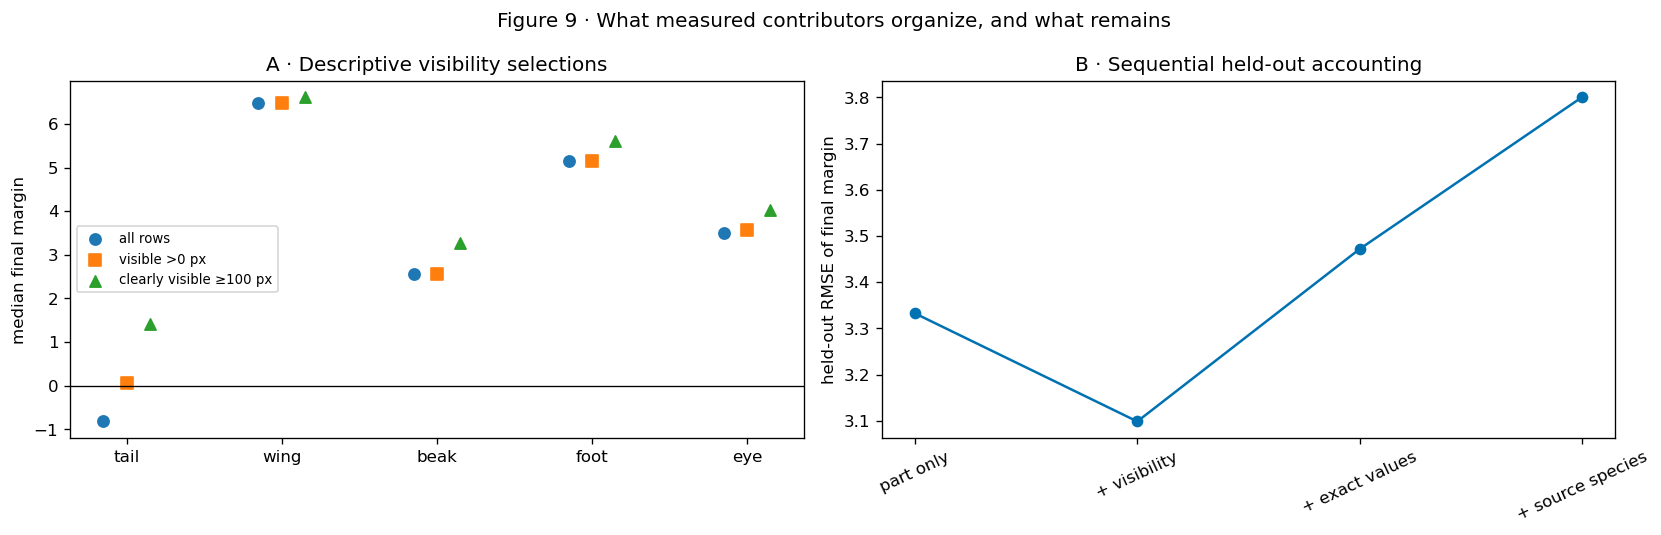

,part,selection,n,median_margin
0,tail,all rows,1000,-0.819
1,tail,visible >0 px,813,0.057
2,tail,clearly visible ≥100 px,390,1.416
3,wing,all rows,1000,6.483
4,wing,visible >0 px,909,6.475
5,wing,clearly visible ≥100 px,794,6.613
6,beak,all rows,1000,2.551
7,beak,visible >0 px,995,2.566
8,beak,clearly visible ≥100 px,521,3.263
9,foot,all rows,1000,5.158


,stage,rmse,mae,split_unit,n_original_images
0,part only,3.333,2.559,orig_render_id,250
1,+ visibility,3.098,2.403,orig_render_id,250
2,+ exact values,3.472,2.617,orig_render_id,250
3,+ source species,3.801,2.899,orig_render_id,250


In [18]:
# ALT: Held-out final-margin prediction error after adding FunnyBird visibility, exact values, and source species sequentially.
import hashlib
A=S.copy(); A["vis_bin"]=pd.cut(A.pixel_count_cf,[-1,19,49,99,199,499,np.inf],labels=False)
original_id_column=next((c for c in ["orig_render_id","source_render_id","li","image_orig","orig_image"] if c in A),None)
if original_id_column is None:
    raise RuntimeError("Figure 9 requires an original source-image identity; swap-row render_id is not an independent split unit")
unit=A[original_id_column].astype(str)
A["fold"]=unit.map(lambda x:int(hashlib.sha1(x.encode()).hexdigest(),16)%5)
if A.groupby(original_id_column).fold.nunique().max()!=1:
    raise RuntimeError("one original source image was assigned to more than one fold")
stages=[("part only",["part"]),("+ visibility",["part","vis_bin"]),
        ("+ exact values",["part","vis_bin","var_src","var_donor"]),
        ("+ source species",["part","vis_bin","var_src","var_donor","sid_src"])]
rows=[]
for stage,cols in stages:
    pred=pd.Series(index=A.index,dtype=float)
    for fold in range(5):
        tr=A[A.fold!=fold]; te=A[A.fold==fold]
        prior=tr.margin.mean(); stats=tr.groupby(cols).margin.agg(["mean","count"]).reset_index()
        stats["estimate"]=(stats["mean"]*stats["count"]+prior*10)/(stats["count"]+10)
        joined=te[cols].merge(stats[cols+["estimate"]],on=cols,how="left")
        pred.loc[te.index]=joined.estimate.fillna(prior).to_numpy()
    rows.append({"stage":stage,"rmse":float(np.sqrt(np.mean((A.margin-pred)**2))),
                 "mae":float(np.mean(np.abs(A.margin-pred)))})
ACCOUNT=pd.DataFrame(rows)
ACCOUNT["split_unit"]=original_id_column
ACCOUNT["n_original_images"]=unit.nunique()
desc=[]
for p in ORDER:
    d=A[A.part==p]
    for label,mask in [("all rows",np.ones(len(d),dtype=bool)),("visible >0 px",d.pixel_count_cf>0),("clearly visible ≥100 px",d.pixel_count_cf>=100)]:
        g=d[mask]; desc.append({"part":p,"selection":label,"n":len(g),"median_margin":g.margin.median()})
DESC=pd.DataFrame(desc)
fig,axes=plt.subplots(1,2,figsize=(14,4.5))
for label,marker,offset in [("all rows","o",-.15),("visible >0 px","s",0),("clearly visible ≥100 px","^",.15)]:
    d=DESC[DESC.selection==label].set_index("part").reindex(ORDER)
    axes[0].scatter(np.arange(len(ORDER))+offset,d.median_margin,label=label,marker=marker,s=45)
axes[0].axhline(0,color="black",lw=.8); axes[0].set_xticks(np.arange(len(ORDER)),ORDER)
axes[0].set_ylabel("median final margin"); axes[0].set_title("A · Descriptive visibility selections"); axes[0].legend(fontsize=8)
axes[1].plot(ACCOUNT.stage,ACCOUNT.rmse,"o-",color="#0072B2")
axes[1].set_ylabel("held-out RMSE of final margin"); axes[1].tick_params(axis="x",rotation=25)
axes[1].set_title("B · Sequential held-out accounting")
fig.suptitle("Figure 9 · What measured contributors organize, and what remains")
plt.tight_layout(); plt.show(); display(DESC.round(3)); display(ACCOUNT.round(3))


    ### Plain-language reference for Figure 9

    **Plain caption.** Visibility improves prediction for unseen source images, while this particular categorical lookup gives exact values and source species no held-out explanatory credit.

    **Terms and how to read it.** A prediction rule maps known row fields to a predicted final margin. Five folds keep every swap from one original image together. RMSE is the square root of mean squared prediction error; lower is better. The x-axis adds visibility, exact pair, then species information sequentially.

    **Literal values.** With all swaps from one original image kept in one fold (250 original images), held-out RMSE improves from 3.333 to 3.098 when visibility is added. It then worsens to 3.472 with exact values and 3.801 with source species; MAE follows the same pattern.

    **Interpretation.** Visibility is the only added block that predicts unseen original images better. Adding exact values or source species makes predictions worse, which means this declared test gives them no generalizing explanatory credit even though earlier descriptive plots show associations.

**Strongest alternative explanation.** There are many exact-value and species combinations but only 250 original images, so some training-fold groups are small. The simple group-average predictor may therefore be a poor model, but that possibility cannot be counted as positive evidence.

    **Discriminating test.** Repeat with independent seeds or predeclare a different predictor before assigning generalizing explanatory credit to exact values or species.

    **Verdict.** **KEEP**.

    **Proof ledger.** `VALID TEST, NO SUPPORT from this predictor that exact values or source species account for held-out margin variance; only visibility gives a small improvement.`

    **Next question.** Does the concept-layer margin have a large downstream class consequence?


## Textbook guide: the measurements are related questions, not interchangeable scores

The aligned figures deliberately put anatomical groups in the same row order,
but the panels do **not** all measure the same thing. FunnyBird has controlled
part replacement; CUB has natural photographs and released masks. We therefore
match the scientific question while naming the weaker CUB approximation.

| Scientific question | FunnyBird measurement | CUB measurement | Same operation? |
|---|---|---|---|
| Are labels present without visible part evidence? | renderer-derived label/visibility conflict | positive label with mapped mask absent | related; CUB masks are noisier |
| Is the concept output usable? | raw-`z` spread, balanced accuracy, positive recall | the same health checks | yes |
| Do named pixels affect the score? | controlled `response_delta` after donor insertion | visible-minus-hidden raw-`z` difference | no; CUB compares different photographs |
| Does context remain after local evidence is limited? | donorward response occurs but old source still wins | hidden positive-minus-negative raw-`z` gap | no; only FunnyBird has a donor/source margin |
| Does species still organize the score? | source-species residual after exact source/donor values | species residual after exact concept and mask state | related and observational |
| Is the exact inserted value recognized? | controlled post-swap value confusion | no clean equivalent | unavailable in CUB |

### Model health comes before grounding

For exact concept `j`, the model predicts positive when `z_ij>0`. Balanced
accuracy gives positive and negative examples equal weight:

`balanced_accuracy = (positive recall + negative recall) / 2`.

If 70% of positive examples and 80% of negative examples are correct, balanced
accuracy is `(0.70+0.80)/2 = 0.75`; the aligned summary plots ordinary concept
error `1-0.75 = 0.25`. A large error says the output is difficult. It does not
say whether the error came from context, weak pixels, or noisy labels.

An output is **collapsed** when its raw score is effectively constant across all
images: `Q95(z)-Q05(z) <= 1e-8`. For example, returning `z=+2.1` for every image
always predicts “present.” Positive recall would misleadingly equal 1, negative
recall would equal 0, and balanced accuracy would equal 0.5. Such an output did
not learn a usable image distinction and cannot support a grounding claim.

The CUB70 model has two exactly collapsed outputs:
`has_throat_color::grey` is constant-positive and
`has_wing_pattern::multi-colored` is constant-negative. They remain visible as
negative health results and are excluded from positive grounding summaries.

### Direction of each CUB panel

| Panel type | A larger value means | Interpretation |
|---|---|---|
| **Data check: positive label / mask absent** | more positive labels lack a usable mapped mask | possible label/visibility conflict, but also possible missing annotation |
| **Health check: ordinary concept error** | worse positive/negative prediction | weak or difficult output; not automatically backwash |
| **Local evidence: visible - hidden raw `z`** | positive examples score higher when the region is visible | evidence that local pixels help; usually a good grounding sign |
| **Context evidence: hidden positive - negative raw `z`** | labels remain separated when the mapped mask is absent | context or unmeasured pixels remain informative |
| **Species context: residual spread** | species shift `z` after exact concept and mask state are centered | species-associated organization remains |

These quantities have different units and directions. They must not be added
into a synthetic “CUB backwash score.” Repeatedly unusual groups are stronger
observational candidates; only a controlled outcome can measure causal
backwash directly.


## 9b · Do the proposed contributors line up with the controlled part ordering?

**Question.** Do the proposed contributors line up with the controlled part ordering?

**Variables and prediction.** Place four separately defined part-level quantities in aligned panels: the controlled backwash-candidate rate, the same rate among swaps with at least 100 target pixels, the training label/mask conflict rate, and one minus exact donor-value recognition. Tail should be high across several contributor panels while wing and foot should be low if the proposed explanation matches the controlled outcome. The panels use different units and must not be added together.

**Method.** Use the same five-part order in every panel and print the exact table.

### Figure 9b · Do the proposed contributors line up with the controlled part ordering?

**How to read the figure.** All four panels use the same y-axis part order. Panel A is the fraction of
all swaps satisfying `response_delta>0 and m_cf<0`. Panel B repeats that
fraction only when the inserted target occupies at least 100 pixels. Panel C
is the fraction of original positive training labels removed by the matched
visibility rule. Panel D is one minus the post-swap inserted-value recognition
rate. Larger is worse in every panel, but the denominators and meanings differ,
so the bar heights must not be added. The shared ordering asks whether the
proposed contributors align with the controlled outcome.


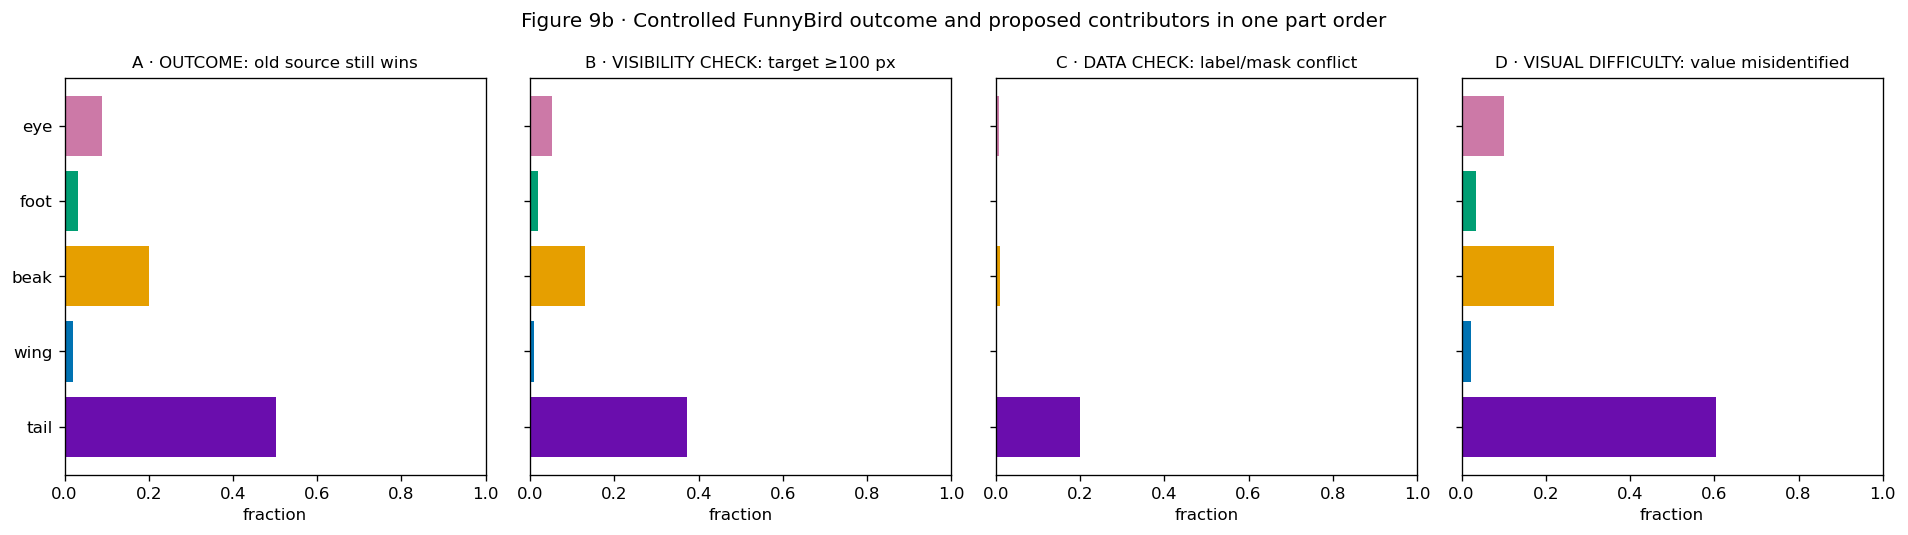

,controlled_backwash_rate,clear_visible_backwash_rate,label_mask_conflict_rate,donor_value_error_rate
part,,,,
tail,0.502,0.372,0.199,0.605
wing,0.019,0.010,0.000,0.023
beak,0.200,0.131,0.010,0.220
foot,0.032,0.017,0.001,0.035
eye,0.089,0.052,0.007,0.100


In [19]:
# ALT: Four aligned FunnyBird part-level panels comparing the controlled backwash outcome with clear-visibility residuals, label/mask conflict, and exact donor-value error.
if "PART_CONFLICT" not in globals():
    raise RuntimeError("Figure 9b requires the matched standard/RLv2 label records used in Figure 6b")
if "diag" not in globals():
    raise RuntimeError("Figure 9b requires the exact-value recognition results from Figure 7")
FB_SYN=pd.DataFrame(index=ORDER)
FB_SYN.index.name="part"
FB_SYN["controlled_backwash_rate"]=(S.groupby("part").responded_but_source_wins.mean().reindex(ORDER))
FB_SYN["clear_visible_backwash_rate"]=(S[S.pixel_count_cf>=100].groupby("part")
                                          .responded_but_source_wins.mean().reindex(ORDER))
FB_SYN["label_mask_conflict_rate"]=PART_CONFLICT.conflict_rate.reindex(ORDER)
FB_SYN["donor_value_error_rate"]=pd.Series({p:1-diag[p] for p in ORDER}).reindex(ORDER)
panels=[
    ("controlled_backwash_rate","A · OUTCOME: old source still wins"),
    ("clear_visible_backwash_rate","B · VISIBILITY CHECK: target ≥100 px"),
    ("label_mask_conflict_rate","C · DATA CHECK: label/mask conflict"),
    ("donor_value_error_rate","D · VISUAL DIFFICULTY: value misidentified"),
]
fig,axes=plt.subplots(1,4,figsize=(16,4.5),sharey=True)
for ax,(column,title) in zip(axes,panels):
    ax.barh(np.arange(len(ORDER)),FB_SYN[column],color=[COLORS[p] for p in ORDER])
    ax.set_xlim(0,1); ax.set_title(title,fontsize=10); ax.set_xlabel("fraction")
    ax.set_yticks(np.arange(len(ORDER)),ORDER); ax.invert_yaxis()
fig.suptitle("Figure 9b · Controlled FunnyBird outcome and proposed contributors in one part order")
plt.tight_layout(); plt.show(); display(FB_SYN.round(3))


### Plain-language reference for Figure 9b

**Plain caption.** The observed part ordering lines up across controlled
backwash, clearly visible swaps, training label/mask conflict, and exact-
value error, but the four bars are not pieces that can be added.

**Terms and denominators.** Panel A uses all 1,000 swaps per part. Panel B
uses only swaps with at least 100 inserted-part pixels. Panel C divides
removed positive training labels by all original positives. Panel D is
one minus the inserted-value recognition rate. Every panel is a fraction,
but the populations and questions differ.

**Literal values.** Controlled event rates are tail `0.502`, beak
`0.200`, eye `0.089`, foot `0.032`, and wing `0.019`. With target area at
least 100 pixels they remain `0.372`, `0.131`, `0.052`, `0.017`, and
`0.010`. Label/mask conflict rates are `0.199`, `0.010`, `0.007`,
`0.001`, and less than `0.001`; donor-value error rates are `0.605`,
`0.220`, `0.100`, `0.035`, and `0.023` in the same part order.

**Interpretation.** The hardest controlled part is also the part with the
most invisible-positive supervision and wrong exact-value answers. That
agreement makes the proposed story plausible, but five correlated part
summaries cannot measure how much each cause contributed.

**Alternative.** Alignment can arise from correlated part properties,
and there are only five anatomical units.

**Discriminating test.** Use the same-row held-out accounting in Figure 9
and the matched RLv2 intervention for label-conflict causality.

**Verdict.** **KEEP**.

**Proof ledger.** Visibility-resistant events, label conflict, and exact-
value difficulty align descriptively with the controlled ordering. They
are not additive and do not fully explain the residual.

**Next question.** Does the concept-layer behavior have a meaningful
downstream species-prediction consequence?


## 10 · Does the concept-layer error materially alter species prediction?

**Question.** Does the concept-layer error materially alter species prediction?

**Variables and prediction.** Relate final concept margin to the model's donor-species probability, which is a different downstream quantity. A small downstream change would limit the harm to explanation reliability rather than widespread class failure.

**Method.** Use independent final-margin bins and print bin counts.

### Figure 10 · Does the concept-layer error materially alter species prediction?

**How to read the figure.** Swaps are divided into ten non-overlapping, approximately equal-count bins by final donor-minus-source concept
margin on the x-axis. The y-axis is the model's mean probability for the donor
species, with the number of rows printed per bin. This asks whether concept
grounding failure has a downstream class effect; it is intentionally the one
place where class probability, rather than raw concept `z`, is the outcome.


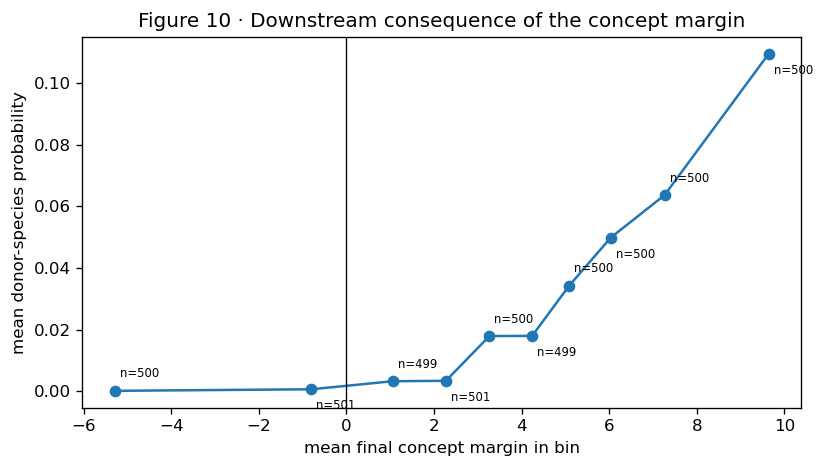

,margin_bin,n,mean_margin,mean_donor_species_prob
0,"(-13.01, -2.175]",500,-5.284,0.000
1,"(-2.175, 0.231]",501,-0.805,0.001
2,"(0.231, 1.715]",499,1.052,0.003
3,"(1.715, 2.802]",501,2.271,0.003
4,"(2.802, 3.777]",500,3.266,0.018
5,"(3.777, 4.674]",499,4.241,0.018
6,"(4.674, 5.519]",500,5.089,0.034
7,"(5.519, 6.562]",500,6.037,0.050
8,"(6.562, 8.086]",500,7.265,0.064
9,"(8.086, 13.957]",500,9.644,0.110


In [20]:
# ALT: Binned relationship between FunnyBird final concept margin and downstream donor-species probability.
prob_col=next((c for c in ["p_cf_donor","p_donor_cf","donor_species_prob"] if c in S),None)
if prob_col is None:
    print("INCOMPLETE: swap CSV has no donor-species probability column")
else:
    D=S.copy(); D["margin_bin"]=pd.qcut(D.margin,10,duplicates="drop")
    Q=D.groupby("margin_bin",observed=True).agg(n=(prob_col,"size"),mean_margin=("margin","mean"),mean_donor_species_prob=(prob_col,"mean")).reset_index()
    fig,ax=plt.subplots(figsize=(7,4)); ax.plot(Q.mean_margin,Q.mean_donor_species_prob,"o-")
    for k,r in enumerate(Q.itertuples()):
        ax.annotate(f"n={r.n}",(r.mean_margin,r.mean_donor_species_prob),
                    fontsize=7,xytext=(3,8 if k%2==0 else -12),
                    textcoords="offset points")
    ax.axvline(0,color="black",lw=.8); ax.set_xlabel("mean final concept margin in bin")
    ax.set_ylabel("mean donor-species probability"); ax.set_title("Figure 10 · Downstream consequence of the concept margin")
    plt.tight_layout(); plt.show(); display(Q.round(3))


    ### Plain-language reference for Figure 10

    **Plain caption.** A more donor-positive concept margin modestly increases the saved model's donor-species probability, linking concept behavior to a downstream consequence.

    **Terms and how to read it.** The x-axis is mean final concept margin inside one of ten disjoint bins. The y-axis is the saved model's mean donor-species probability. This is the only main figure using class probability rather than raw concept `z`.

    **Literal values.** Mean donor-species probability rises monotonically from approximately zero in negative-margin bins to 0.110 in the most donor-positive bin, with 499-501 rows per bin.

    **Interpretation.** When the donor concept finishes farther ahead, the model becomes more willing to predict the donor species. The probability still reaches only 11% in the strongest bin because the other four parts and the body still belong to the source bird.

**Strongest alternative explanation.** A one-part replacement need not make the whole donor species plausible because the unchanged body and other parts still belong to the source.

    **Discriminating test.** Replicate across seeds and compare class-logit changes, not only final probability.

    **Verdict.** **KEEP**.

    **Proof ledger.** `ACCEPTED FOR a monotone but modest single-swap downstream donor-species effect; the primary harm here is explanation fidelity.`

    **Next question.** Does minimality change the accepted standard-CBM quantities?


## 11 · Standard-CBM evidence ledger

| Predicate or explanation | Direct measurement | Status after review |
|---|---|---|
| model outputs are usable | Figure 1 | `ACCEPTED FOR SEED-1 MODEL HEALTH` |
| interventions are valid | Figure 2 | `ACCEPTED FOR CONTROLLED ONE-PART REPLACEMENT` |
| inserted pixels cause donorward movement | Figure 3 | `ACCEPTED FOR ALL FIVE PARTS` |
| starting preference versus donor rise/source release | Figure 3b | `ACCEPTED ARITHMETIC DECOMPOSITION` |
| old source can remain stronger after that movement | Figure 4 | `ACCEPTED FOR GRADED CONTROLLED BACKWASH` |
| donor wins versus two distinct failure states | Figure 4b | `ACCEPTED OUTCOME PARTITION` |
| direction artifact excluded | Figure 5 | `ACCEPTED; ORDERING HOLDS BOTH DIRECTIONS` |
| visibility contribution | Figure 6 | `ACCEPTED AS CONTRIBUTOR, NOT SUFFICIENT` |
| training label/mask conflict measured | Figure 6b | `ACCEPTED DATA ASSOCIATION; CAUSAL TEST IS 02RL` |
| exact-value contribution | Figure 7 | `ACCEPTED AS GRADED CONTRIBUTOR` |
| frequency/alternative-count explanation | Figure 7b | `MIXED; NO SUFFICIENT MONOTONE EXPLANATION` |
| source-species residual | Figure 8 | `DESCRIPTIVE ASSOCIATION ONLY` |
| species information beyond concept-label buckets | Figure 8b | `ACCEPTED FOR AVAILABILITY, NOT GROUNDING` |
| existing saved class head uses within-label magnitudes | Figure 8c | `INCOMPLETE PENDING RENDERED EXISTING-HEAD TEST` |
| off-target source fingerprint predicts controlled failure | Figure 8d | `INCOMPLETE PENDING RENDERED CONTROLLED LINK` |
| sequential same-row accounting and residual | Figure 9 | `VISIBILITY IMPROVES HELD-OUT ERROR; EXACT VALUE/SPECIES DO NOT` |
| aligned contributor view | Figure 9b | `ACCEPTED DESCRIPTIVELY; NOT ADDITIVE OR CAUSAL` |
| downstream class consequence | Figure 10 | `ACCEPTED FOR MODEST MONOTONE ASSOCIATION` |

### Limited conclusion

**Backwash exists in this seed-1 Standard CBM.** It is not necessary for
all parts to fail identically: the controlled predicate is row-level,
and its prevalence is graded from tail through wing. The renderer changes
the intended pixels, every part responds donorward, and in a measured
subset the final concept answer nevertheless remains attached to the old
source.

The three proposed contributors were all investigated. Visibility
accounts for some held-out organization but leaves many clearly visible
tail events. Label/mask conflict and exact-value error closely match the
part ordering, with tail highest and wing/foot lowest, but their current
standard-model analyses are associations. Rarity/support is mixed.
Source species strongly appears in the learned concept representation
and in descriptive residuals, yet adding source species worsens held-out
margin prediction under the declared categorical estimator. Figures 8c
and 8d now supply the missing discriminating chain: first test whether the
saved CBM head actually uses within-label magnitudes, then test whether
its off-target source fingerprint accompanies controlled failure. Until
those new figures are rendered and reviewed, distributed species leakage
is a candidate mechanism rather than an accepted explanation. Therefore
the evidence does **not** support saying that backwash is fully explained
or that the measured contributors exhaust every causal pathway.

### Why fixed `-3/+3` or `-5/+5` targets are not yet the answer

This Standard CBM does not use an MCBM prototype target. Notebook 03 asks
that separate question. A prototype penalty can remove within-label score
variation, but it does not specify which pixels must produce the target.
A network can recognize the species/body and output the correct prototype
on ordinary training images. A red-to-blue swap with ideal `-5/+5`
outputs changes the donor coordinate by `+10`, the source coordinate by
`-10`, and therefore moves the donor-minus-source margin by `+20`, not
`+10`. Achieving that counterfactual movement requires swap-aware or
spatial grounding supervision; prototype compression alone does not
require it.

### Explicit handoff to the next requested evidence

| Requested follow-up | Where it belongs | What it must establish |
|---|---|---|
| relabelled CBM | notebook 02rl | causal effect of changing positive labels when the named part is invisible |
| raw `z` for each occluded part under Standard versus RLv2 | notebook 02rl | whether the matched relabeling changes hidden/visible score behavior on the same fixed renders |
| Standard CBM and MCBM on CUB70 | notebooks 05 and 06 | observational natural-image replication without inventing a renderer swap |
| CUB70 hidden/visible raw `z` comparison | notebooks 05/06 | released-mask approximation with mask coverage and confounds retained |
| segmentation or spatial routing | later method decision | only pursue if the accepted evidence requires an explicit named-pixel path constraint |

The controlled FunnyBird swap remains the definition-quality base case.
CUB can reproduce questions using natural visibility, mask conflict,
exact-concept difficulty, and species-conditioned raw scores, but those
are weaker observational approximations—not donor/source margins and not
substitutes for the FunnyBird causal result.

**Next report question.** Only after this ledger is reviewed may notebook
03 ask whether MCBM minimality changes the accepted standard-CBM
quantities. MCBM cannot replace this discovery.


# Methods appendix · measurements not used in the main claim

The reciprocal mask-deletion and randomized-patch experiments are retained
as method-development history. They did not reproduce the clean FunnyBird
control sufficiently to transfer their causal interpretation to CUB.

- reciprocal mask deletion: `METHOD NOT CALIBRATED FOR CROSS-DATASET CAUSAL COMPARISON`;
- randomized patch V1/V2: local pixel response was measurable in selected
  examples, but the all-part control was not calibrated and wing coverage was
  inadequate;
- none of these outcomes invalidates the validated renderer swap above.

Full artifacts and scripts remain under `analysis/paired_mask_deletion.py`,
`analysis/randomized_patch_masking.py`, and their output directories. They
are not rerun by this notebook.


# Provenance appendix

The table below records the live Git commit, input paths and SHA-256
hashes, row counts, seed, and the accepted fixed-render root. It is part
of the report: a stale HTML is not synchronized evidence.


In [21]:
def sha256_file(path):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for block in iter(lambda:f.read(1024*1024),b""): h.update(block)
    return h.hexdigest()
commit=subprocess.run(["git","rev-parse","HEAD"],cwd=REPO,capture_output=True,text=True,check=True).stdout.strip()
prov=[]
for role,path in [("fixed-render swap CSV",SWAP),("prediction export",PRED),("model checkpoint",MODEL)]:
    prov.append({"role":role,"path":str(path),"sha256":sha256_file(path)})
display(pd.DataFrame(prov)); display(pd.DataFrame([{"git_commit":commit,"seed":1,
    "swap_rows":len(S),"prediction_images":len(c_saved),"exact_concepts":len(CONCEPT_NAMES),
    "excluded_swap_rows":0,"accepted_render_root":str(SWAP.parent)}]))


,role,path,sha256
0,fixed-render swap CSV,/scratch/network/cr7998/cv_emergence_project/c...,ad3229c059f6d13d960af41fb595fa76ada790a1ea623b...
1,prediction export,/scratch/network/cr7998/cv_emergence_project/c...,2594466992eeb9c3df0eae2308633a0c9d4462c403483e...
2,model checkpoint,/scratch/network/cr7998/cv_emergence_project/c...,12559285506c179526fad4dd3c244f61a24635cadbe80b...


,git_commit,seed,swap_rows,prediction_images,exact_concepts,excluded_swap_rows,accepted_render_root
0,f5126db40aaff1771cf60aa3678513097048d4ca,1,5000,500,26,0,/scratch/network/cr7998/cv_emergence_project/c...
